In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Paths: adjust if needed ---
candidate_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/candidate_cleaned.xlsx")
test_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/test_cleaned.xlsx")

# Outputs will be written in the same folder as inputs
output_dir = candidate_path.parent

candidate_outliers_csv = output_dir / "candidate_outliers.csv"
test_outliers_csv = output_dir / "test_outliers.csv"

candidate_clean_no_outliers_xlsx = output_dir / "candidate_cleaned_no_outliers.xlsx"
test_clean_no_outliers_xlsx = output_dir / "test_cleaned_no_outliers.xlsx"


def detect_outliers_iqr(df: pd.DataFrame, k: float = 1.5):
    """Return outlier flags per numeric column using IQR rule.

    For each numeric column col:
        Q1, Q3 = 25%, 75% quantiles
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        flag if value < lower or value > upper

    Returns
    -------
    flags : DataFrame (bool)
        Same index as df, columns `<col>_is_outlier` for numeric columns.
    any_outlier : Series (bool)
        Row-wise flag: True if any numeric column is outlier.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    flags = pd.DataFrame(index=df.index)

    for col in numeric_cols:
        series = df[col].dropna()
        if series.empty:
            # nothing to compute for this column
            flags[f"{col}_is_outlier"] = False
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        # If IQR is zero, skip this column (no spread)
        if iqr == 0:
            flags[f"{col}_is_outlier"] = False
            continue

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        col_flag = (df[col] < lower) | (df[col] > upper)
        flags[f"{col}_is_outlier"] = col_flag.fillna(False)

    any_outlier = flags.any(axis=1)
    return flags, any_outlier


# --- Load data ---
print("Reading cleaned candidate and test datasets...")
candidate_df = pd.read_excel(candidate_path)
test_df = pd.read_excel(test_path)

print(f"Candidate shape: {candidate_df.shape}")
print(f"Test shape: {test_df.shape}")

# --- Candidate outlier detection ---
print("\nRunning IQR-based outlier detection for candidate data...")
candidate_flags, candidate_any = detect_outliers_iqr(candidate_df, k=1.5)

candidate_with_flags = pd.concat([candidate_df, candidate_flags], axis=1)
candidate_with_flags["any_outlier"] = candidate_any

candidate_outliers = candidate_with_flags[candidate_with_flags["any_outlier"]]

print(f"Candidate outlier rows: {candidate_outliers.shape[0]}")

# Save outlier rows (with flag columns) to CSV
candidate_outliers.to_csv(candidate_outliers_csv, index=False)
print(f"Candidate outliers saved to: {candidate_outliers_csv}")

# Save candidate data with outliers removed
candidate_no_outliers = candidate_with_flags[~candidate_with_flags["any_outlier"]]
# Drop flag columns before saving the cleaned version
flag_cols_candidate = [c for c in candidate_no_outliers.columns if c.endswith("_is_outlier") or c == "any_outlier"]
candidate_no_outliers_clean = candidate_no_outliers.drop(columns=flag_cols_candidate)

candidate_no_outliers_clean.to_excel(candidate_clean_no_outliers_xlsx, index=False)
print(f"Candidate cleaned (no outliers) saved to: {candidate_clean_no_outliers_xlsx}")


# --- Test outlier detection ---
print("\nRunning IQR-based outlier detection for test data...")
test_flags, test_any = detect_outliers_iqr(test_df, k=1.5)

test_with_flags = pd.concat([test_df, test_flags], axis=1)
test_with_flags["any_outlier"] = test_any

test_outliers = test_with_flags[test_with_flags["any_outlier"]]

print(f"Test outlier rows: {test_outliers.shape[0]}")

# Save outlier rows (with flag columns) to CSV
test_outliers.to_csv(test_outliers_csv, index=False)
print(f"Test outliers saved to: {test_outliers_csv}")

# Save test data with outliers removed
flag_cols_test = [c for c in test_with_flags.columns if c.endswith("_is_outlier") or c == "any_outlier"]
test_no_outliers = test_with_flags[~test_with_flags["any_outlier"]]
test_no_outliers_clean = test_no_outliers.drop(columns=flag_cols_test)

test_no_outliers_clean.to_excel(test_clean_no_outliers_xlsx, index=False)
print(f"Test cleaned (no outliers) saved to: {test_clean_no_outliers_xlsx}")

print("\nDone.")

Reading cleaned candidate and test datasets...
Candidate shape: (5000, 41)
Test shape: (27830, 21)

Running IQR-based outlier detection for candidate data...
Candidate outlier rows: 148
Candidate outliers saved to: /Users/ankit/Downloads/EDA-Team assignment/candidate_outliers.csv
Candidate cleaned (no outliers) saved to: /Users/ankit/Downloads/EDA-Team assignment/candidate_cleaned_no_outliers.xlsx

Running IQR-based outlier detection for test data...
Test outlier rows: 2861
Test outliers saved to: /Users/ankit/Downloads/EDA-Team assignment/test_outliers.csv
Test cleaned (no outliers) saved to: /Users/ankit/Downloads/EDA-Team assignment/test_cleaned_no_outliers.xlsx

Done.


Candidate numeric columns: ['CANDIDATE_ID', 'BIRTH_YEAR', 'STUDIED_FOR_GED', 'STUDY_HELPFUL_ADULT_EDUCATION_CLASS', 'STUDY_HELPFUL_ADULT_EDUCATION_TEACHER', 'STUDY_HELPFUL_AUDIO_STUDY_MATERIALS', 'STUDY_HELPFUL_BOOKS_PRINTED_STUDY_MATERIAL', 'STUDY_HELPFUL_GED_READY', 'STUDY_HELPFUL_MATERIALS_MOBILE_APP', 'STUDY_HELPFUL_ONLINE_COURSE_VIDEO_STUDY_MATERIALS', 'STUDY_HELPFUL_OTHER', 'STUDY_HELPFUL_SOCIAL_NETWORKING_WEBSITE', 'STUDY_HELPFUL_TV_STUDY_PROGRAM', 'STUDY_LOCATION_TEST_PREPARATION_CENTER', 'INDIAN_OR_ALASKAN', 'ASIAN', 'AFRICAN_AMERICAN', 'RACE_DECLINE', 'WHITE', 'RACE_NONE', 'HAWAIIAN_OR_PACIFIC', 'CREDENTIAL_DATE_MISSING']
Test numeric columns: ['CANDIDATE_ID', 'ON_VUE', 'GED_READY', 'RESULT_ID', 'SCORE', 'FIRST_COMPLETE', 'FIRST_PASSED', 'MAKE_COMPLETE', 'MAKE_PASSED', 'RESULT_ID_MISSING', 'SCORE_MISSING', 'EXAM_START_MISSING']
Saved candidate numeric distribution summary to: /Users/ankit/Downloads/EDA-Team assignment/candidate_numeric_distribution_summary.csv
Saved test nume

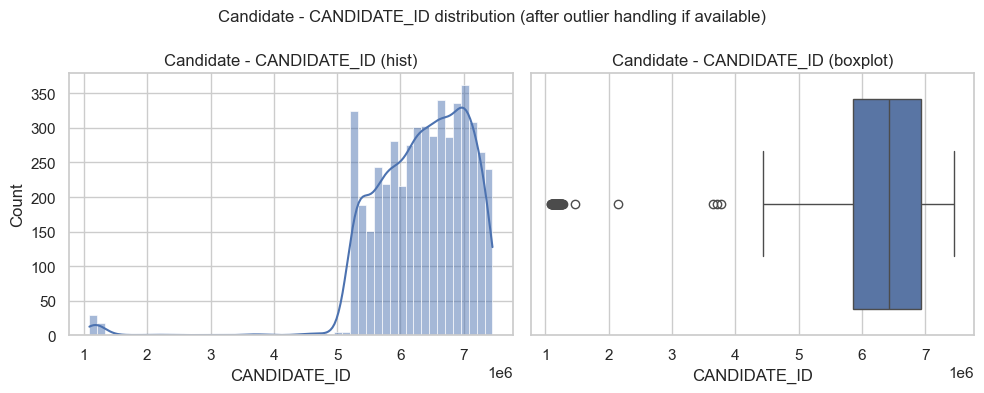

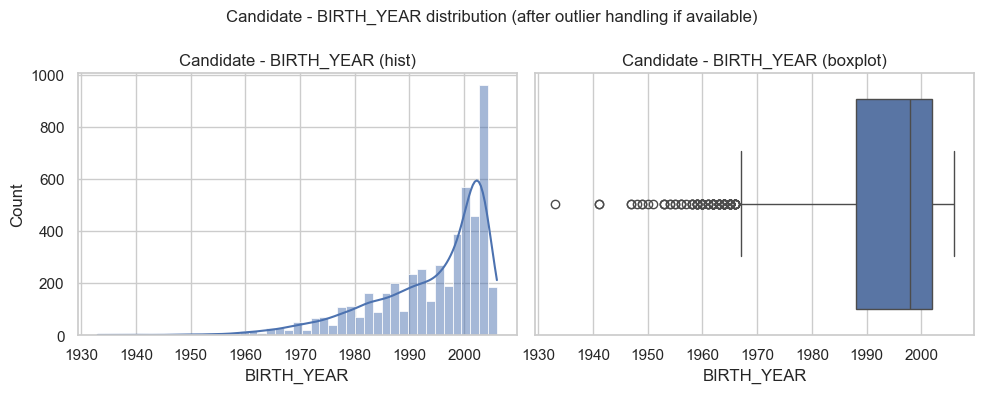

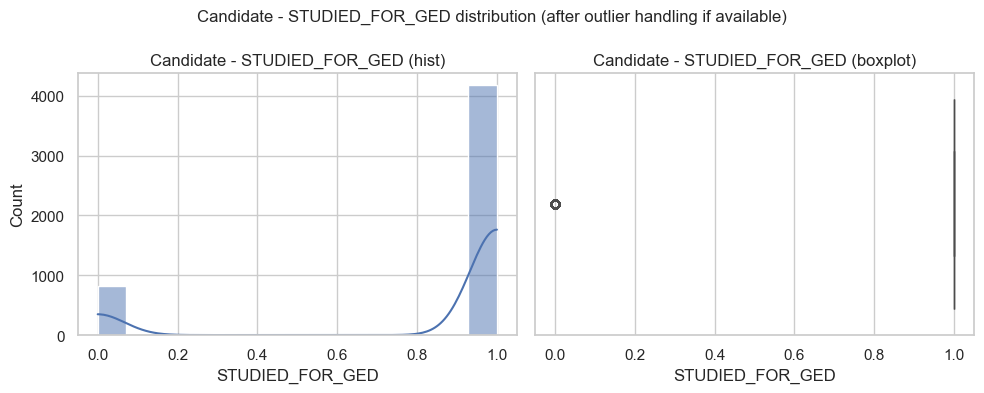

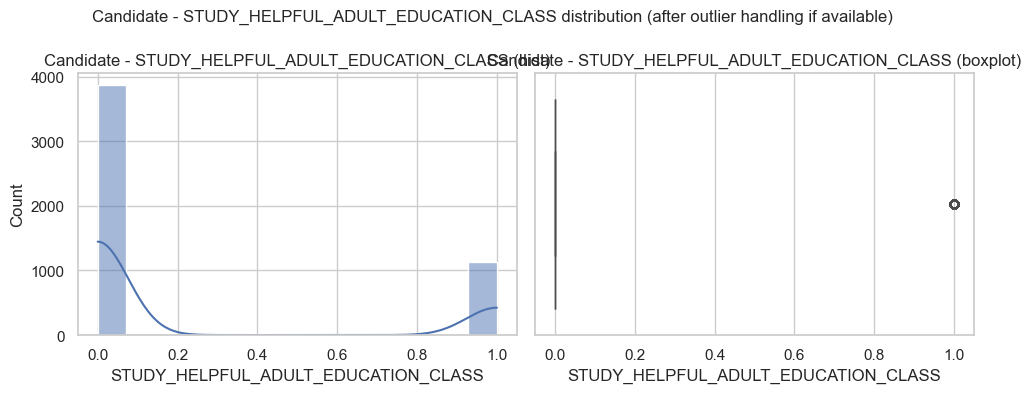

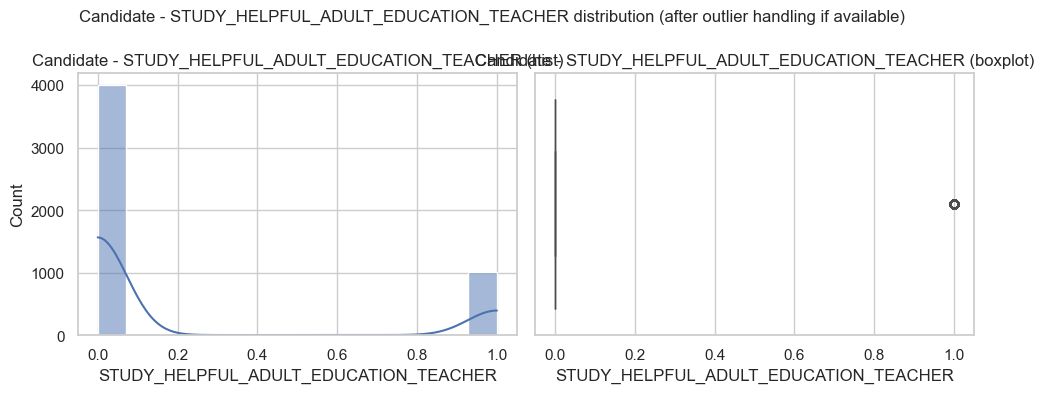

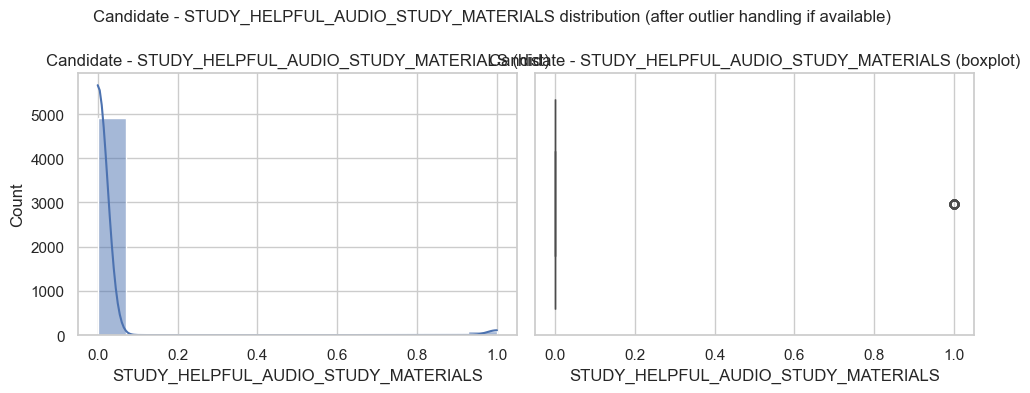

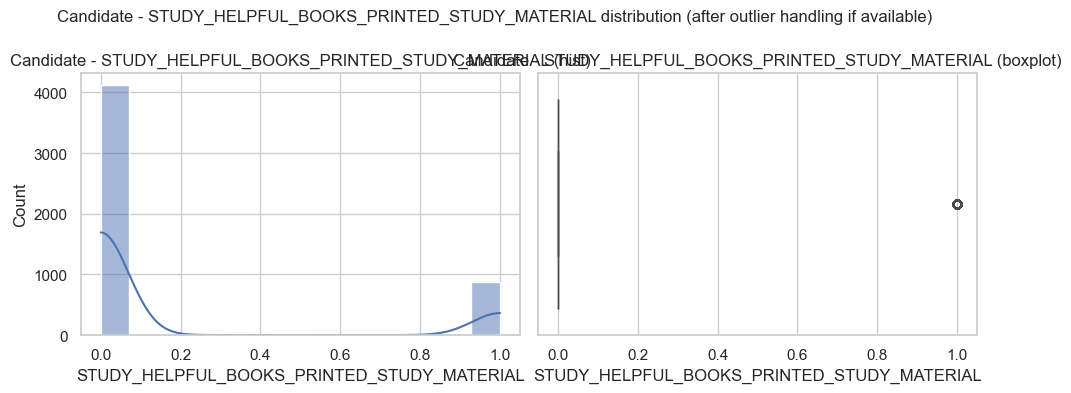

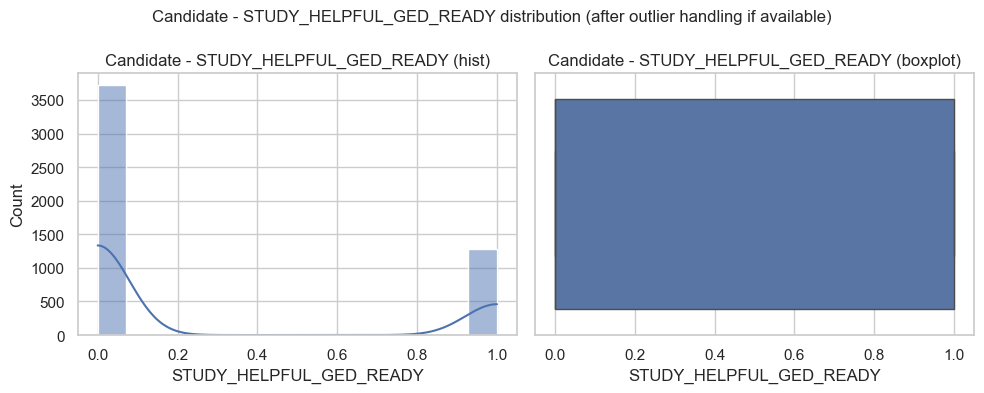

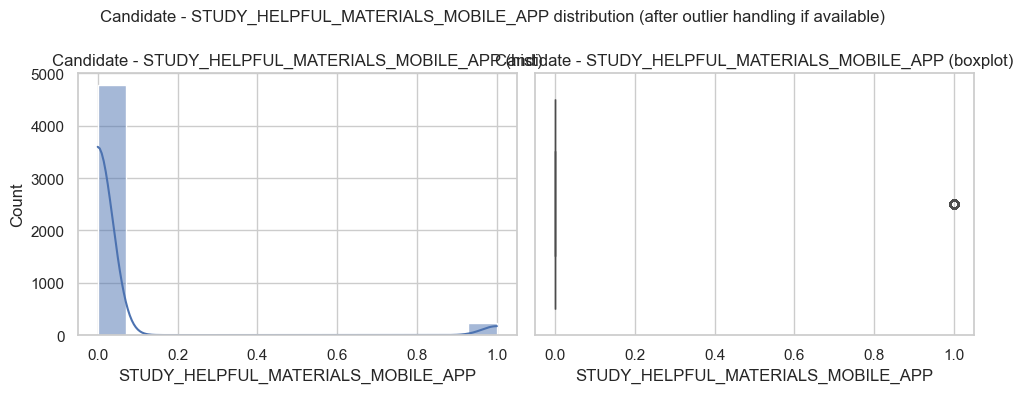

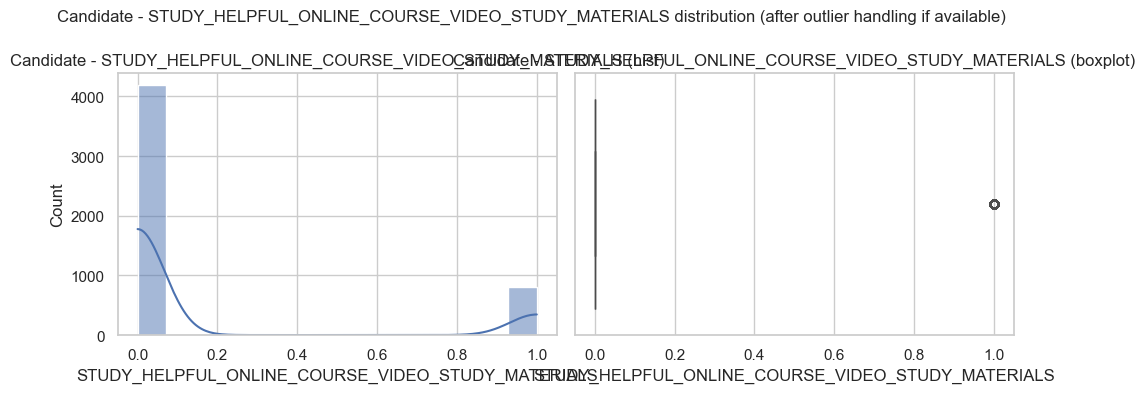

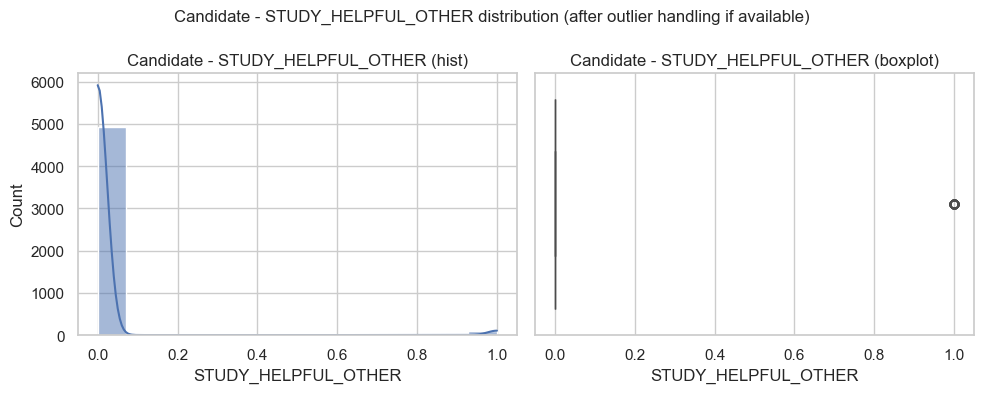

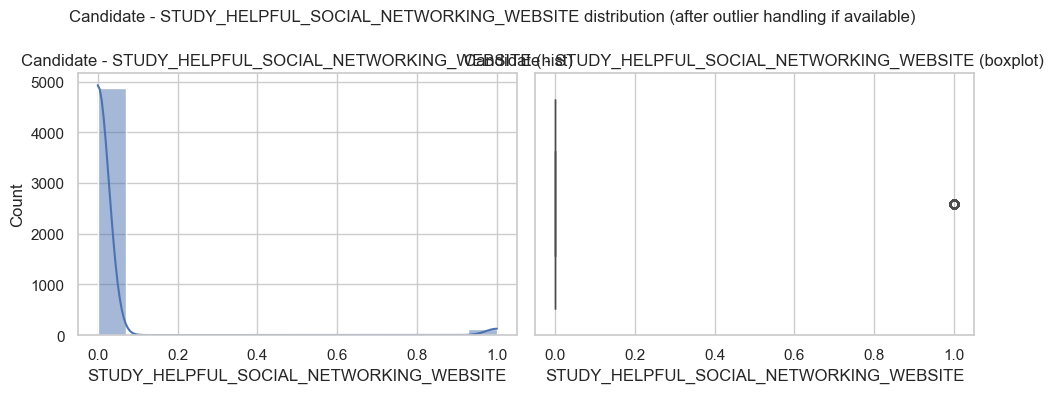

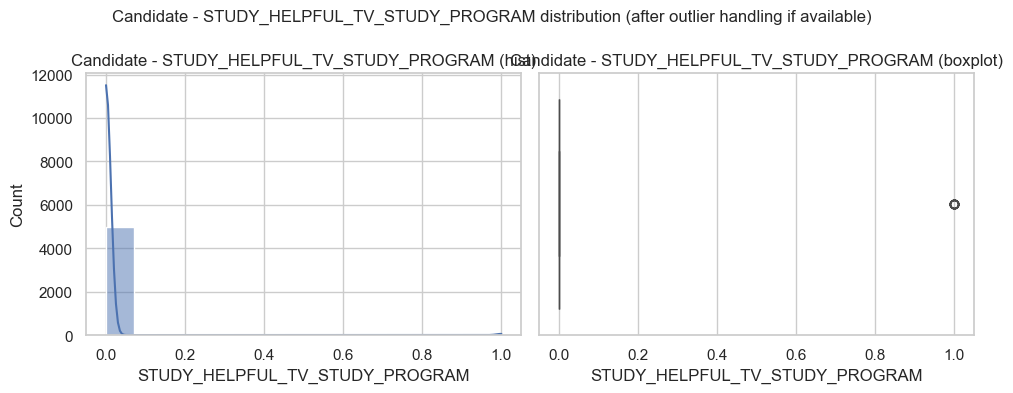

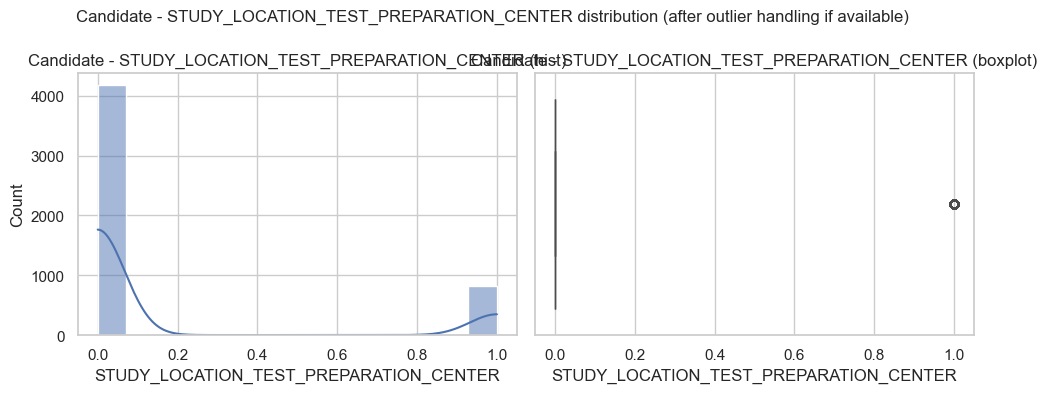

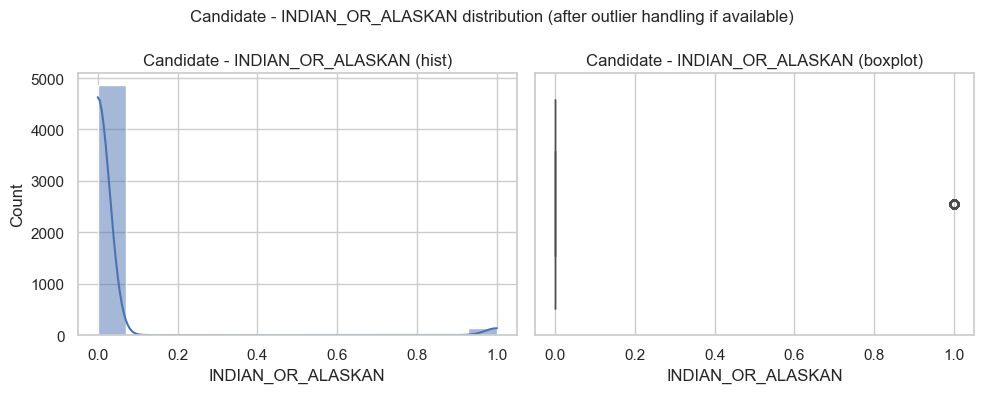

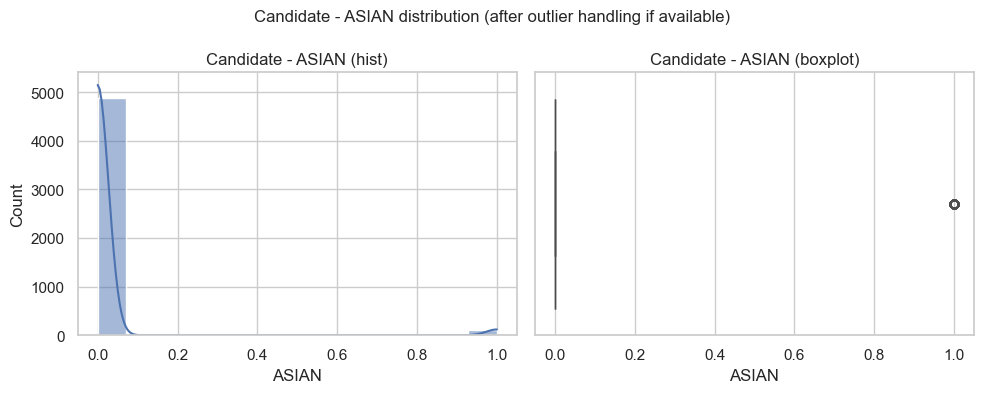

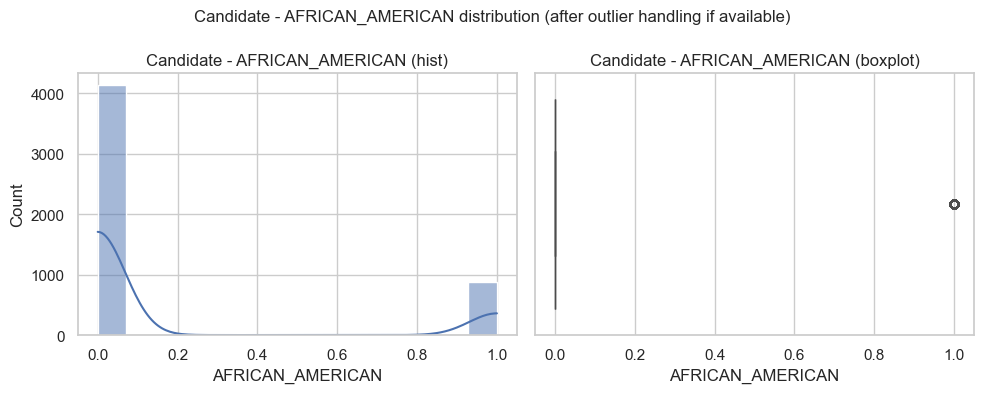

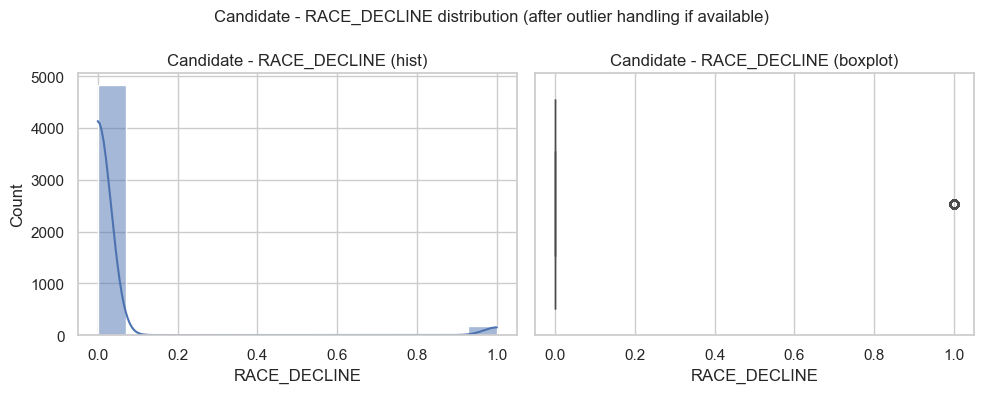

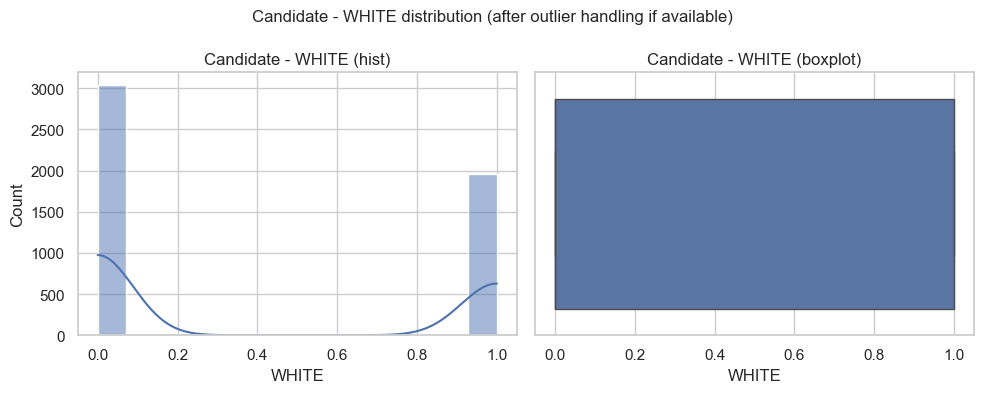

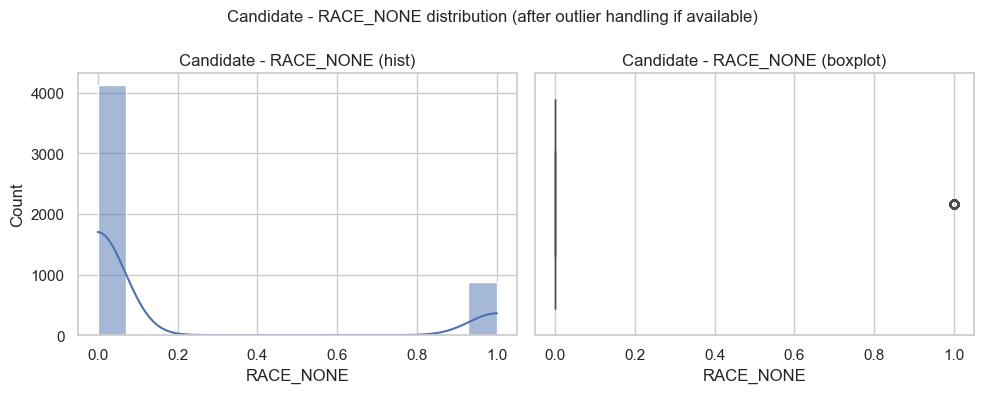

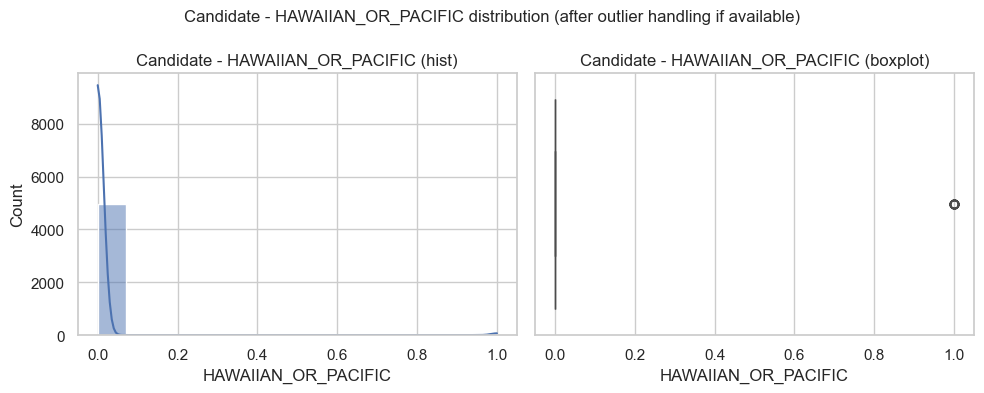

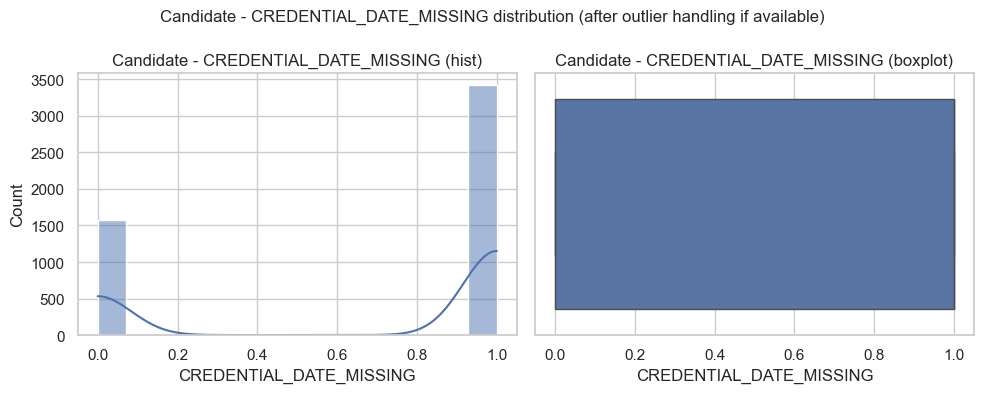

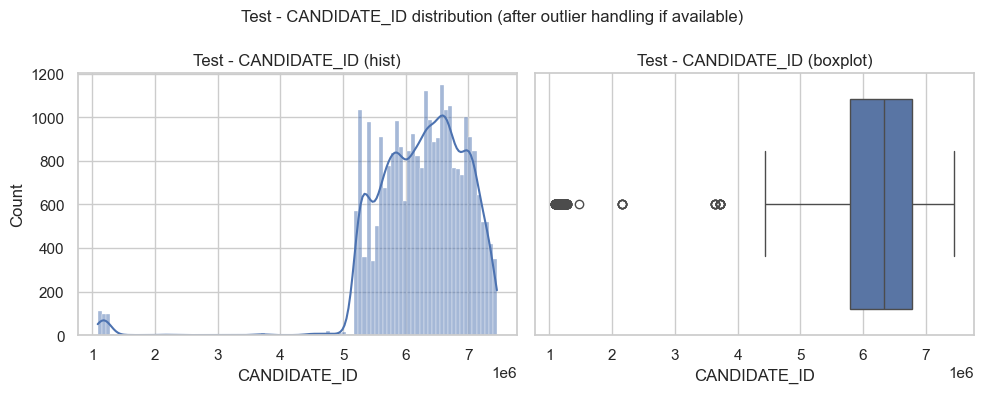

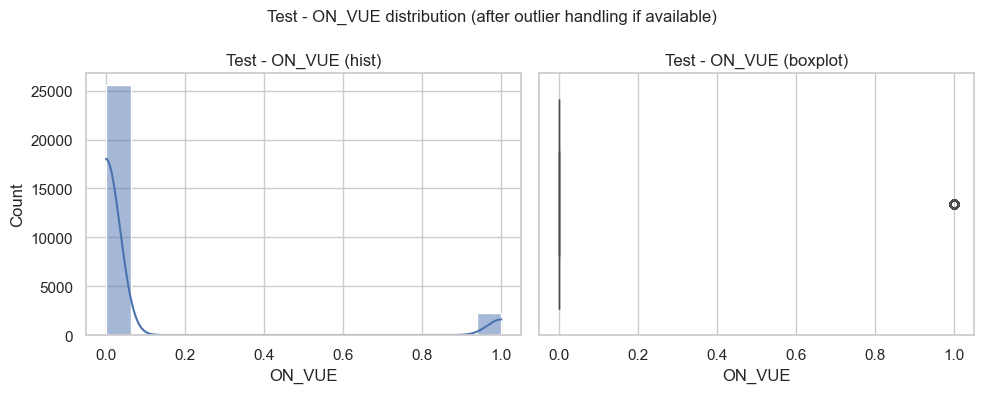

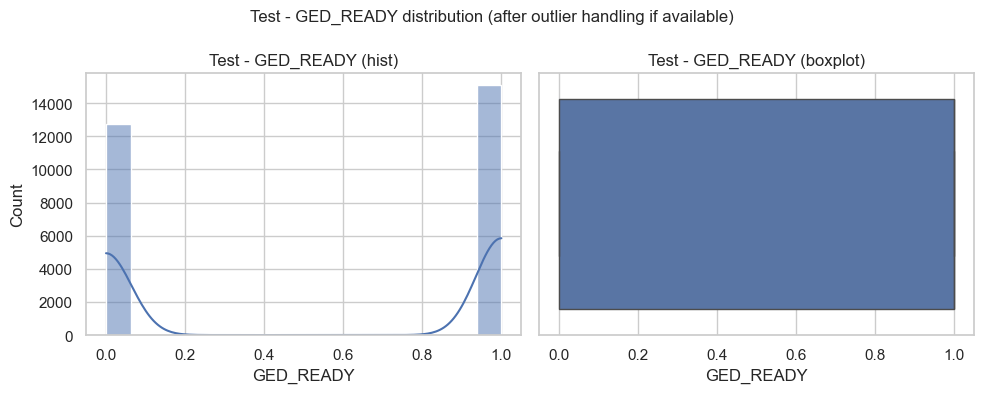

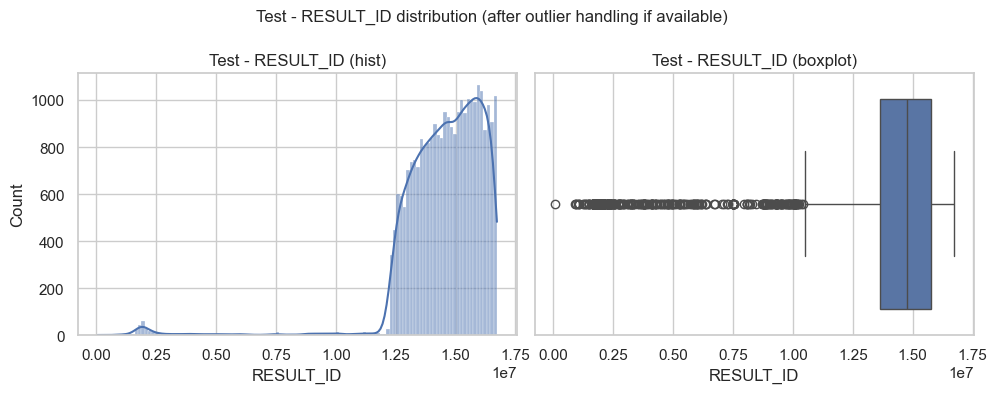

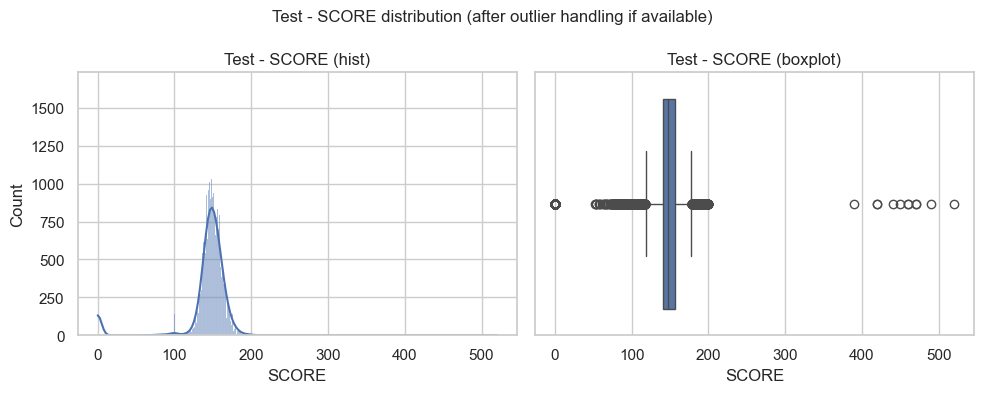

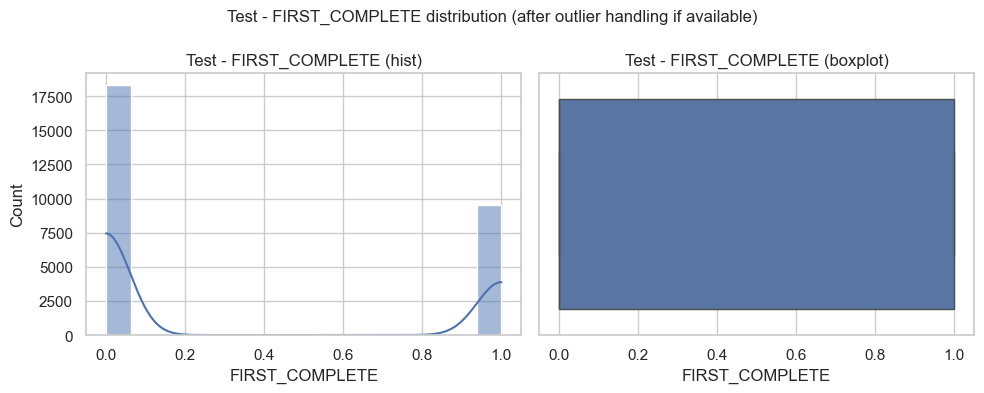

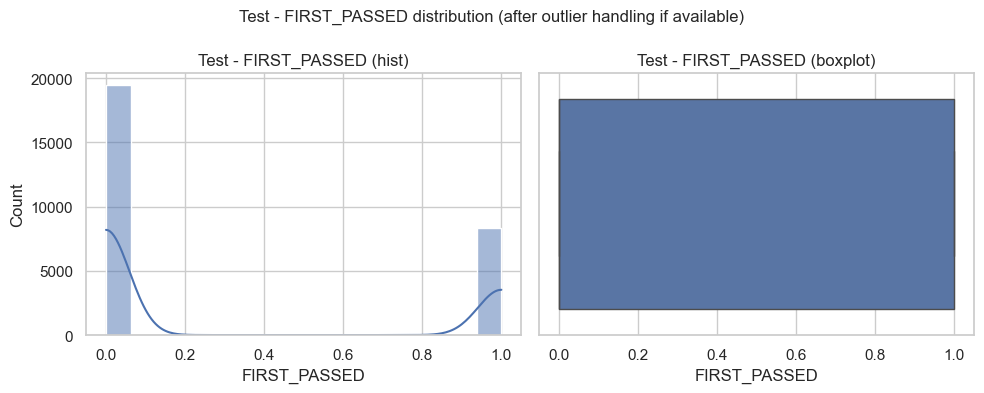

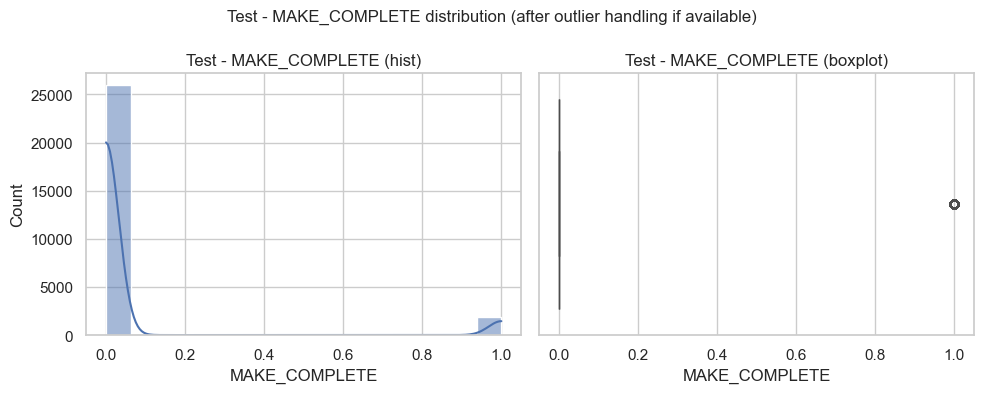

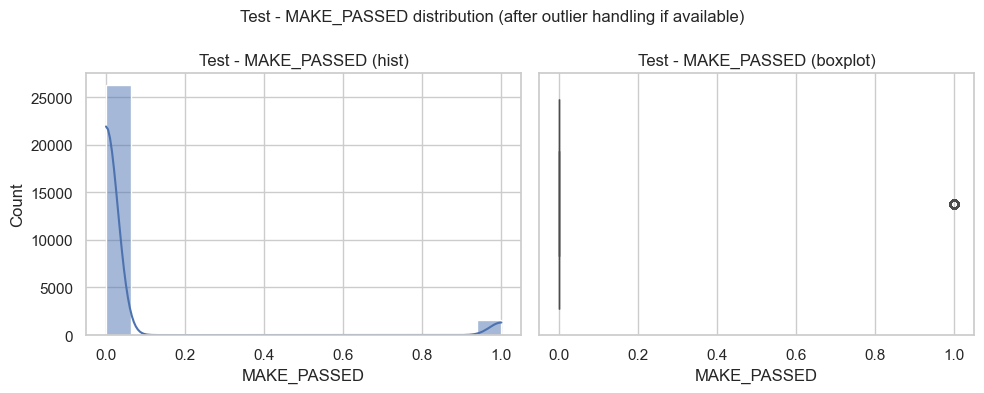

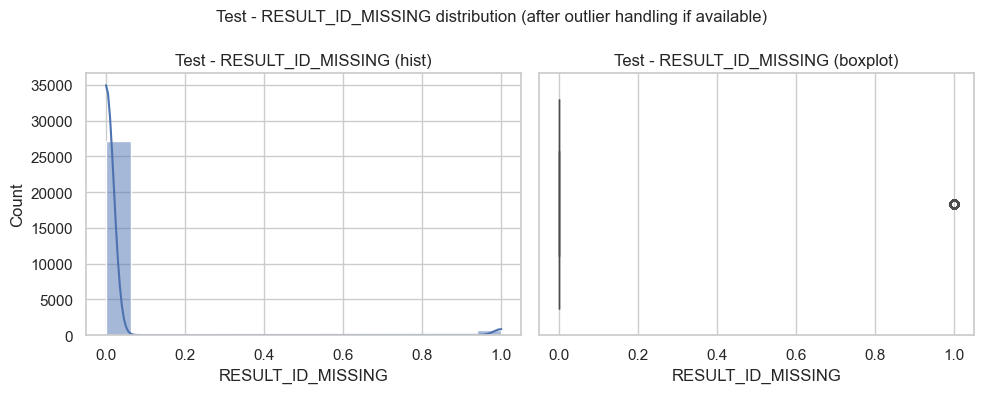

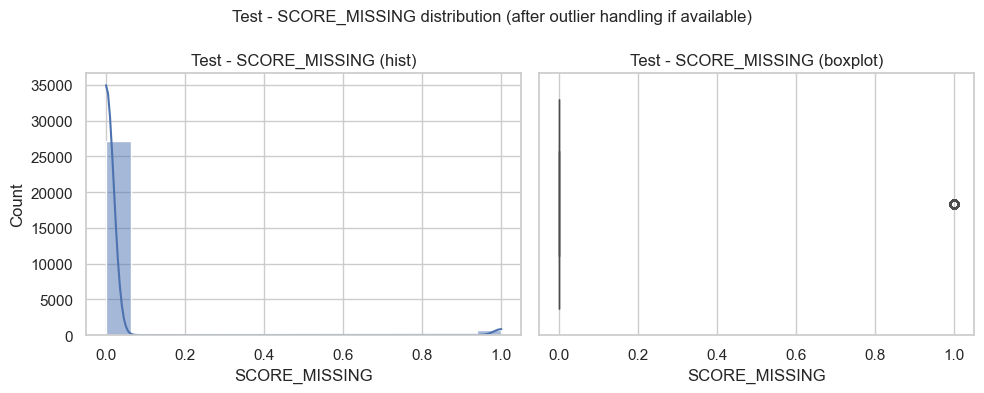

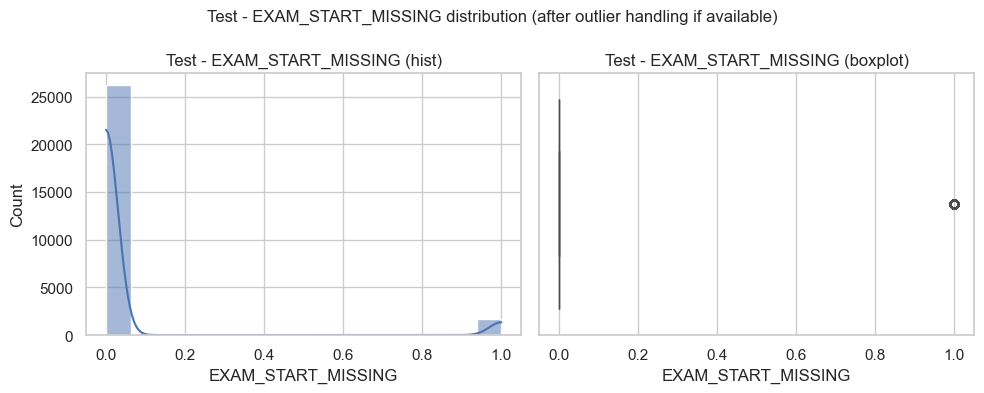

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

# Prefer to use outlier-removed datasets for assumption / distribution checks.
# If they do not exist yet, fall back to the baseline cleaned files.
base_candidate_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/candidate_cleaned.xlsx")
base_test_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/test_cleaned.xlsx")

no_outlier_candidate_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/candidate_cleaned_no_outliers.xlsx")
no_outlier_test_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/test_cleaned_no_outliers.xlsx")

if 'candidate_df' not in globals():
    if no_outlier_candidate_path.exists():
        print("Loading candidate data from outlier-removed file...")
        candidate_df = pd.read_excel(no_outlier_candidate_path)
    else:
        print("Outlier-removed candidate file not found; loading baseline cleaned file...")
        candidate_df = pd.read_excel(base_candidate_path)

if 'test_df' not in globals():
    if no_outlier_test_path.exists():
        print("Loading test data from outlier-removed file...")
        test_df = pd.read_excel(no_outlier_test_path)
    else:
        print("Outlier-removed test file not found; loading baseline cleaned file...")
        test_df = pd.read_excel(base_test_path)

output_dir = base_candidate_path.parent

# Focus on numeric columns only for distribution checks
candidate_num_cols = candidate_df.select_dtypes(include=np.number).columns.tolist()
test_num_cols = test_df.select_dtypes(include=np.number).columns.tolist()

print("Candidate numeric columns:", candidate_num_cols)
print("Test numeric columns:", test_num_cols)

# Save basic distribution statistics for numeric variables (mean, median, quantiles, etc.)
candidate_desc = candidate_df[candidate_num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
test_desc = test_df[test_num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T

candidate_desc.to_csv(output_dir / "candidate_numeric_distribution_summary.csv")
test_desc.to_csv(output_dir / "test_numeric_distribution_summary.csv")

print("Saved candidate numeric distribution summary to:", output_dir / "candidate_numeric_distribution_summary.csv")
print("Saved test numeric distribution summary to:", output_dir / "test_numeric_distribution_summary.csv")

# Plot histograms + boxplots to visually check distributions and remaining potential outliers
sns.set(style="whitegrid")

for col in candidate_num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(candidate_df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Candidate - {col} (hist)")

    sns.boxplot(x=candidate_df[col], ax=axes[1])
    axes[1].set_title(f"Candidate - {col} (boxplot)")

    fig.suptitle(f"Candidate - {col} distribution (after outlier handling if available)", fontsize=12)
    plt.tight_layout()
    plt.show()

for col in test_num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(test_df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Test - {col} (hist)")

    sns.boxplot(x=test_df[col], ax=axes[1])
    axes[1].set_title(f"Test - {col} (boxplot)")

    fig.suptitle(f"Test - {col} distribution (after outlier handling if available)", fontsize=12)
    plt.tight_layout()
    plt.show()

In [1]:
# Quick summary: how many rows were removed as outliers?

import pandas as pd
from pathlib import Path

base_candidate_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/candidate_cleaned.xlsx")
base_test_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/test_cleaned.xlsx")

candidate_no_outliers_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/candidate_cleaned_no_outliers.xlsx")
test_no_outliers_path = Path(r"/Users/ankit/Downloads/EDA-Team assignment/test_cleaned_no_outliers.xlsx")

# Load original cleaned data
candidate_orig = pd.read_excel(base_candidate_path)
test_orig = pd.read_excel(base_test_path)

# Load outlier-removed data
candidate_no_outliers = pd.read_excel(candidate_no_outliers_path)
test_no_outliers = pd.read_excel(test_no_outliers_path)

cand_total = len(candidate_orig)
cand_after = len(candidate_no_outliers)
cand_removed = cand_total - cand_after
cand_ratio = cand_removed / cand_total if cand_total > 0 else 0

test_total = len(test_orig)
test_after = len(test_no_outliers)
test_removed = test_total - test_after
test_ratio = test_removed / test_total if test_total > 0 else 0

print("Candidate table:")
print(f"  Total rows before: {cand_total}")
print(f"  Rows removed as outliers: {cand_removed}")
print(f"  Percentage removed: {cand_ratio:.2%}")

print("\nTest table:")
print(f"  Total rows before: {test_total}")
print(f"  Rows removed as outliers: {test_removed}")
print(f"  Percentage removed: {test_ratio:.2%}")

Candidate table:
  Total rows before: 5000
  Rows removed as outliers: 148
  Percentage removed: 2.96%

Test table:
  Total rows before: 27830
  Rows removed as outliers: 2861
  Percentage removed: 10.28%


Reading baseline cleaned datasets...
Candidate shape before outlier removal: (5000, 41)
Test shape before outlier removal: (27830, 21)

Running IQR-based outlier detection for candidate data (k=3.0)...
Candidate outlier rows (k=3.0): 51
Candidate outliers (k=3.0) saved to: /Users/ankit/Downloads/EDA-Team assignment/candidate_outliers_k3.csv
Candidate cleaned (no outliers, k=3.0) saved to: /Users/ankit/Downloads/EDA-Team assignment/candidate_cleaned_no_outliers_k3.xlsx

Running IQR-based outlier detection for test data (k=3.0)...
Test outlier rows (k=3.0): 2135
Test outliers (k=3.0) saved to: /Users/ankit/Downloads/EDA-Team assignment/test_outliers_k3.csv
Test cleaned (no outliers, k=3.0) saved to: /Users/ankit/Downloads/EDA-Team assignment/test_cleaned_no_outliers_k3.xlsx

Running distribution checks on outlier-removed data (k=3.0)...
Candidate numeric columns (k=3.0 cleaned): ['CANDIDATE_ID', 'BIRTH_YEAR', 'STUDIED_FOR_GED', 'STUDY_HELPFUL_ADULT_EDUCATION_CLASS', 'STUDY_HELPFUL_ADULT_

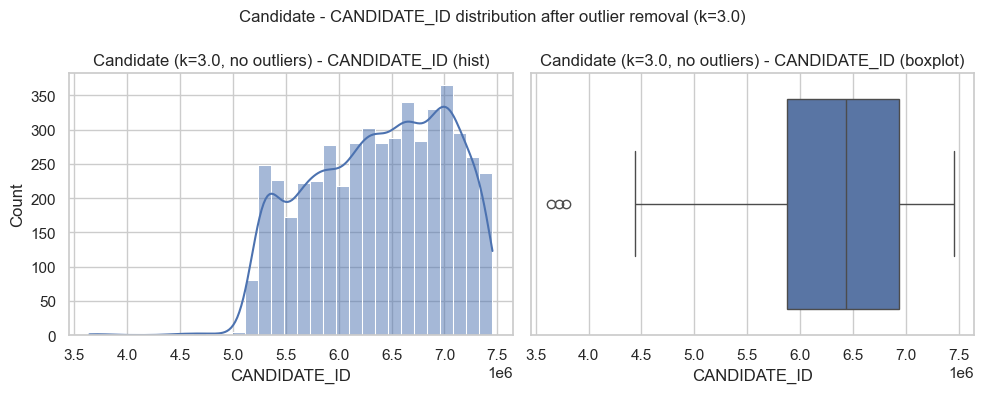

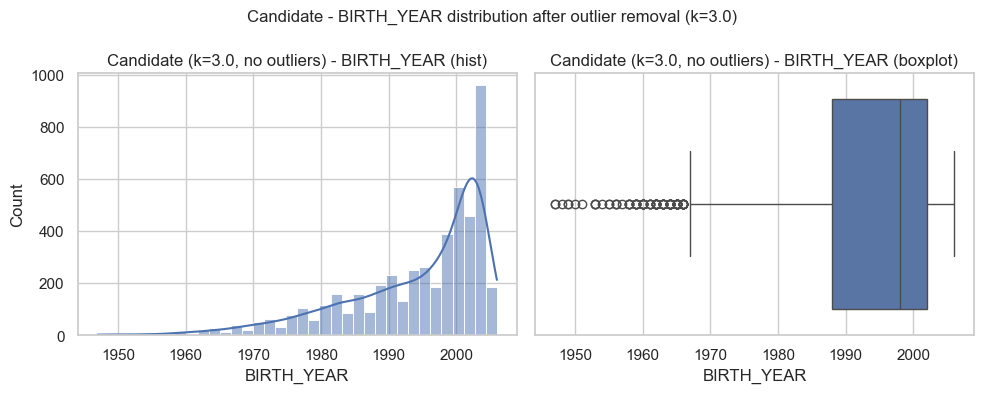

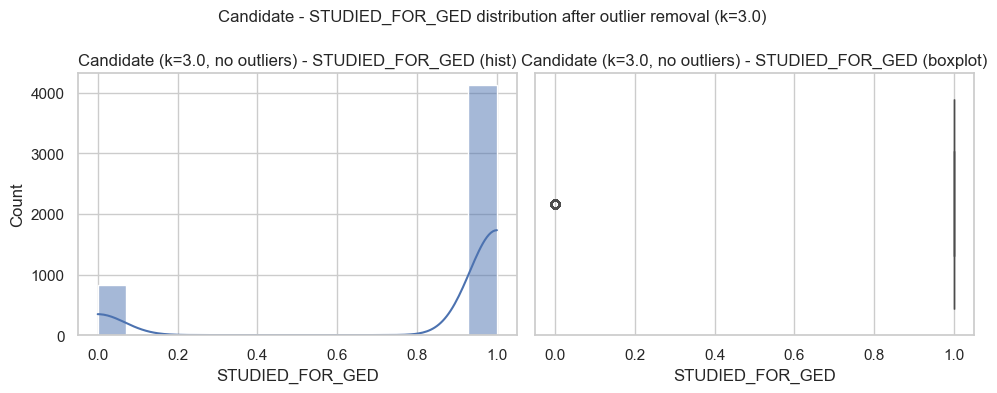

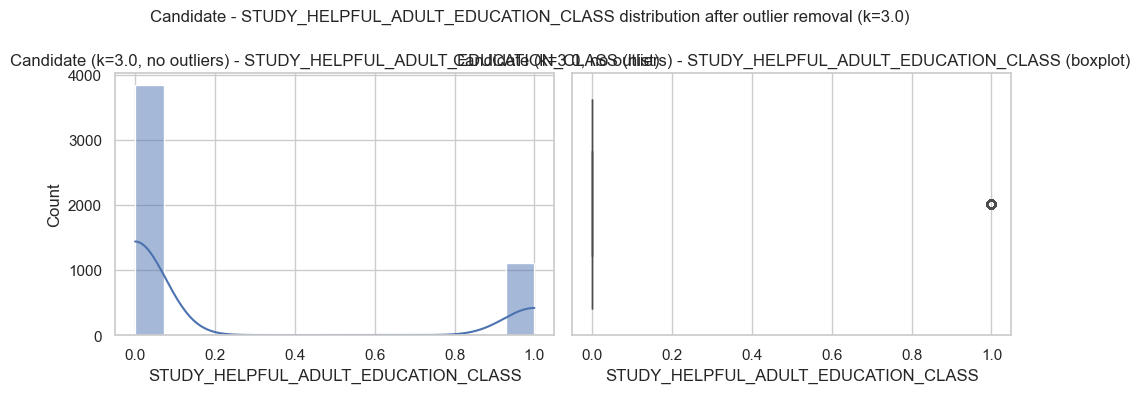

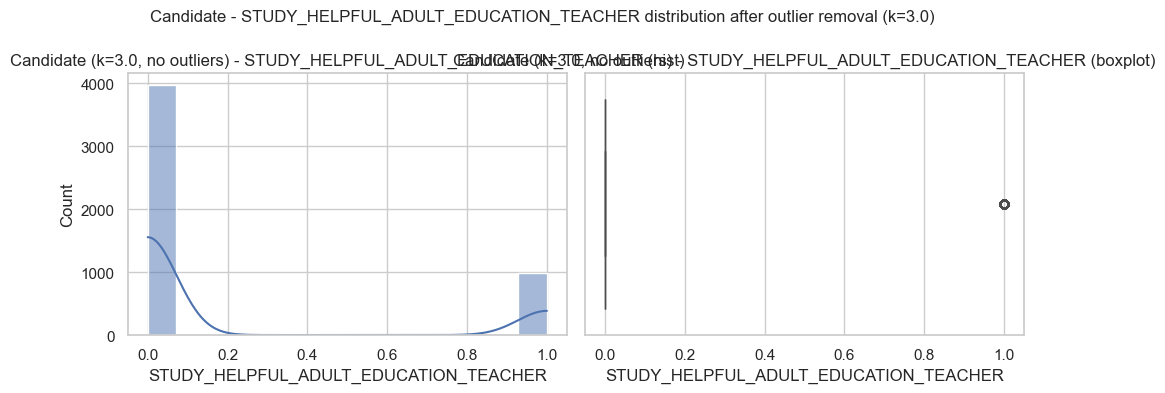

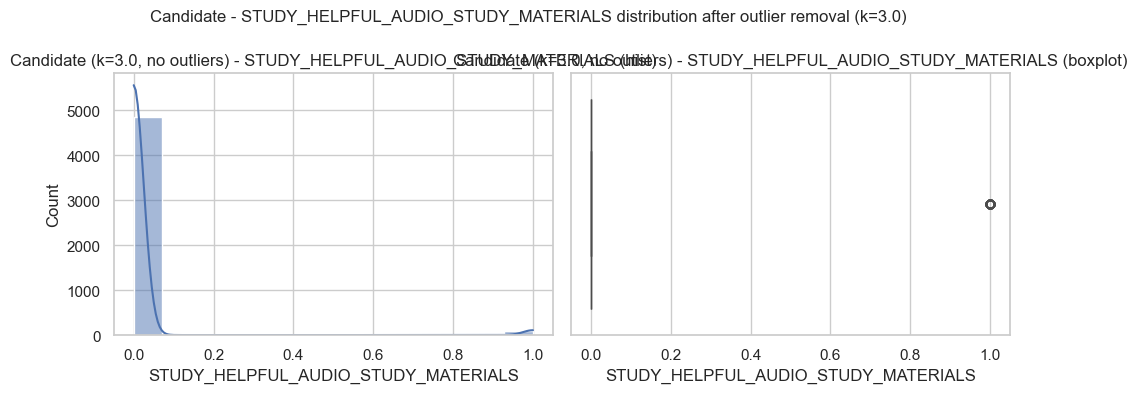

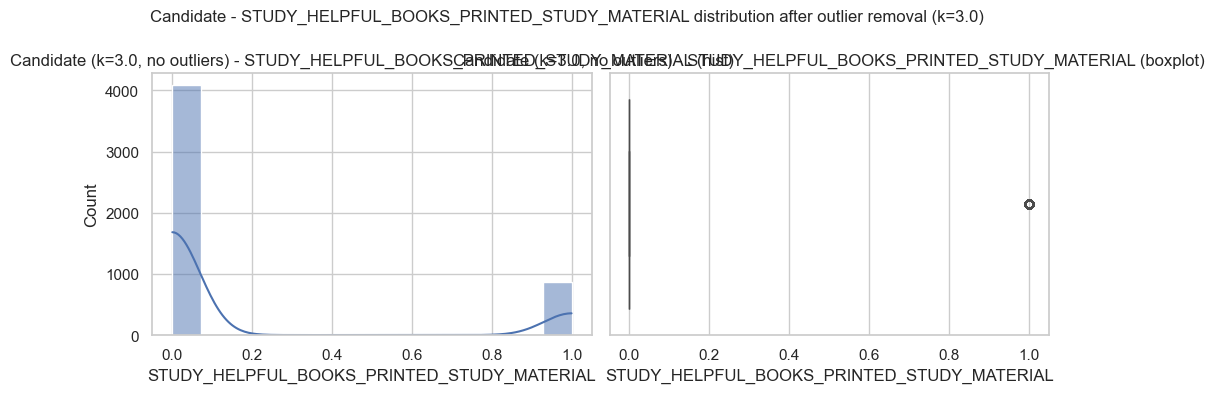

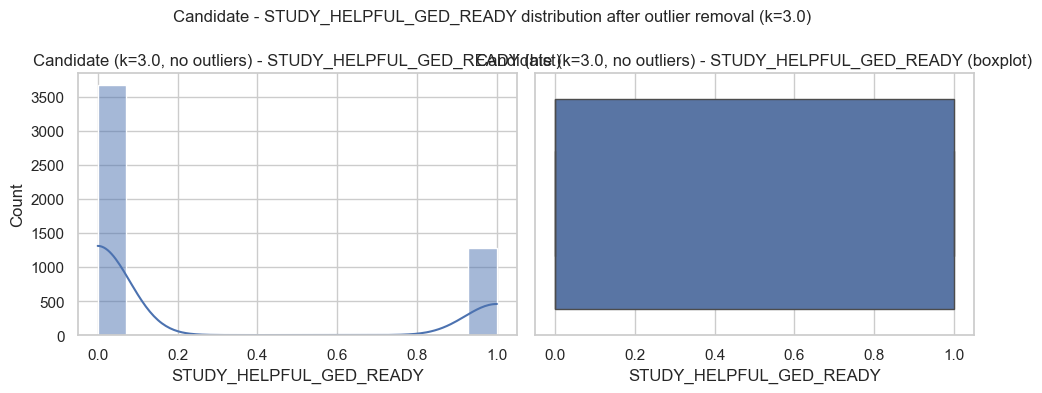

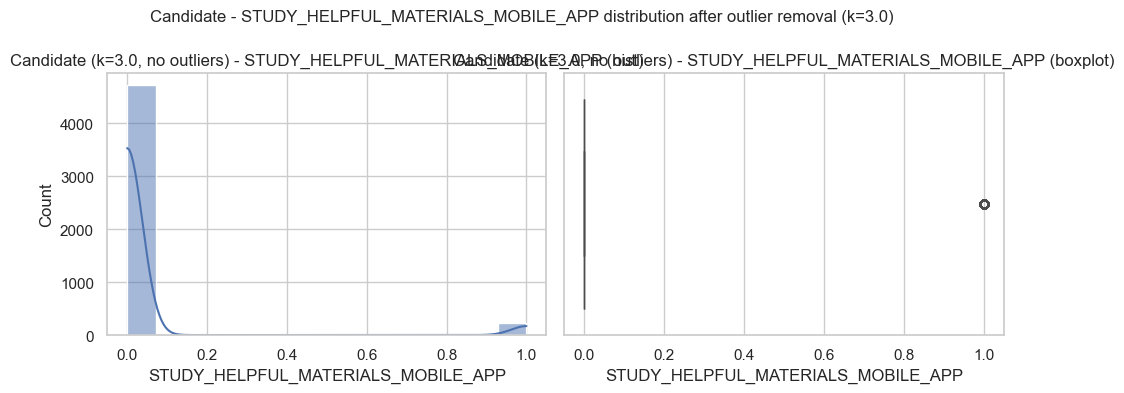

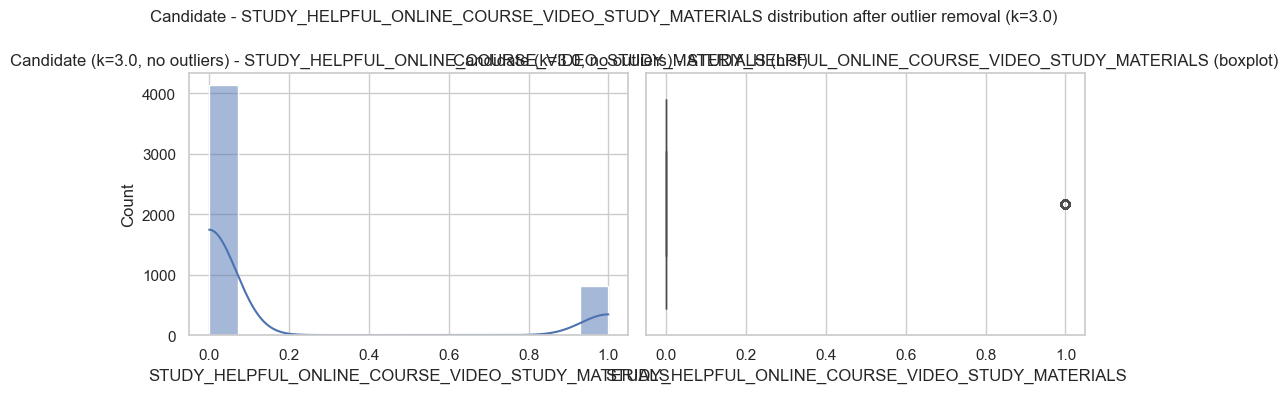

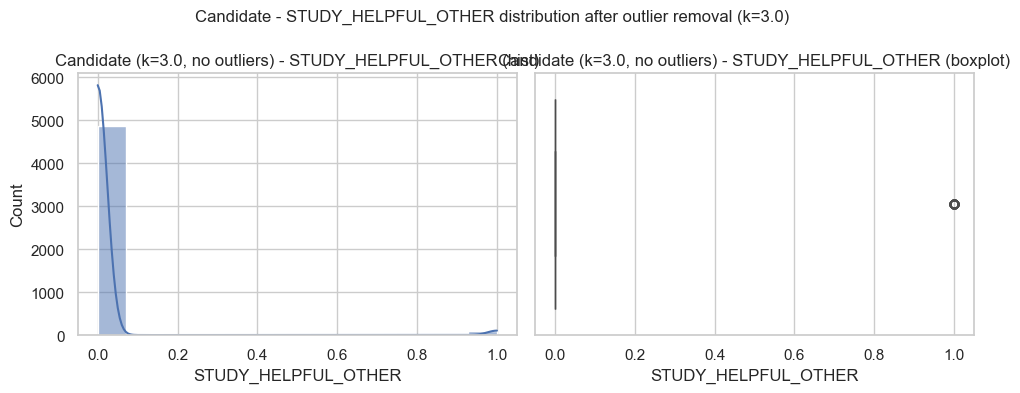

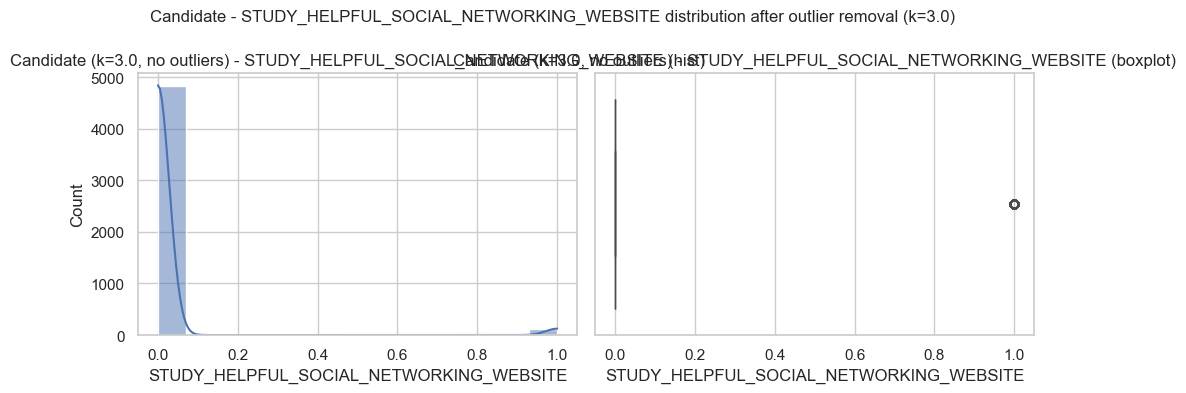

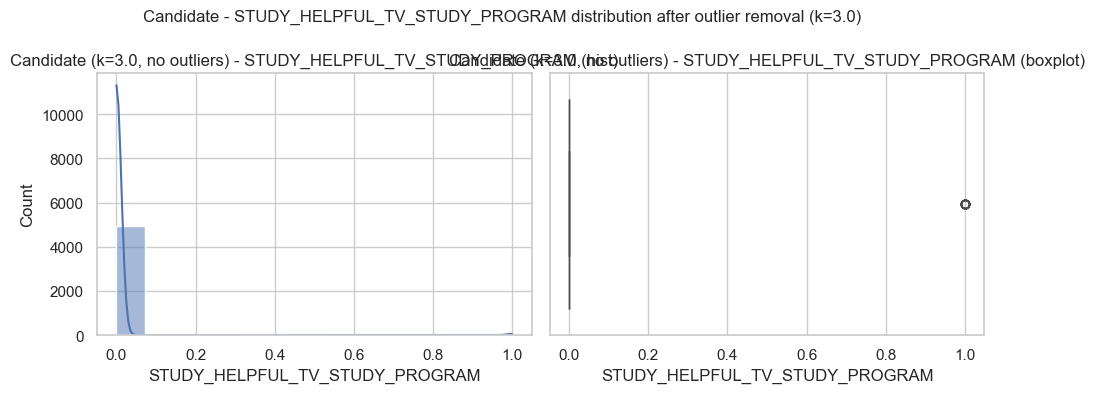

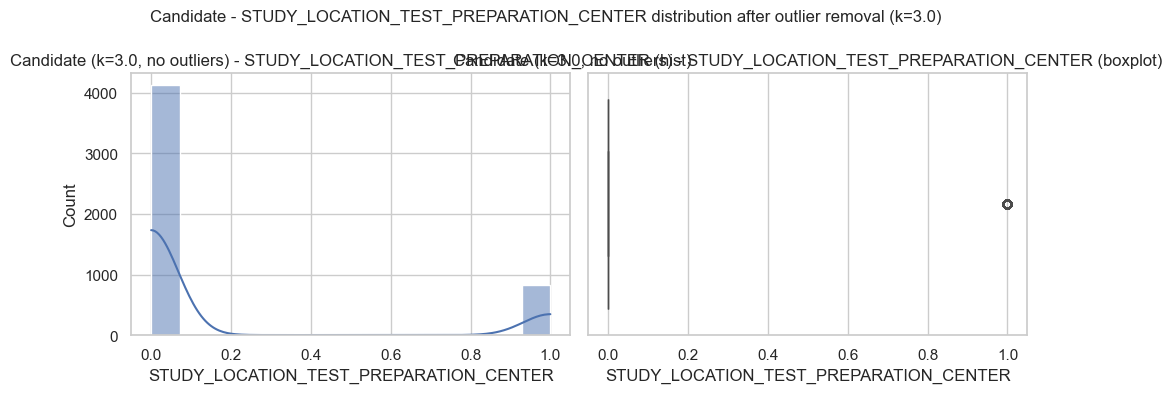

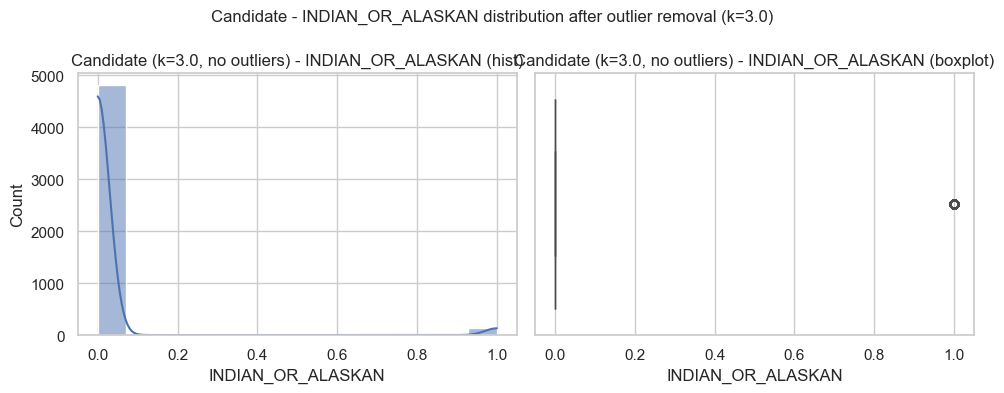

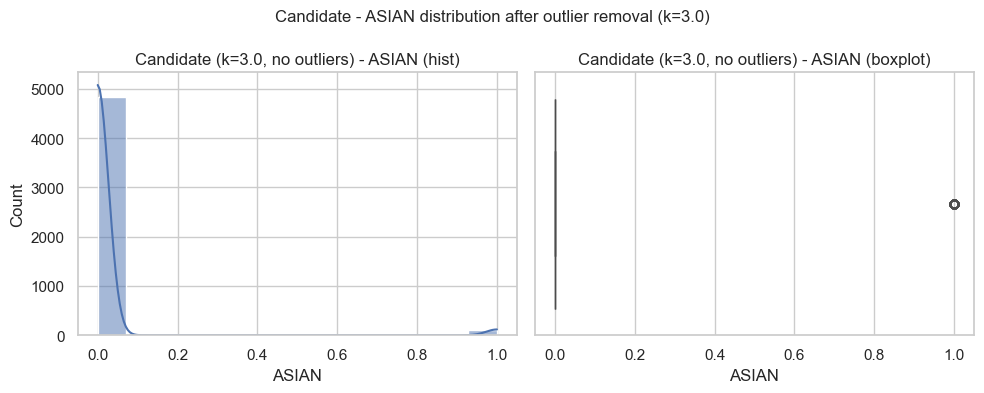

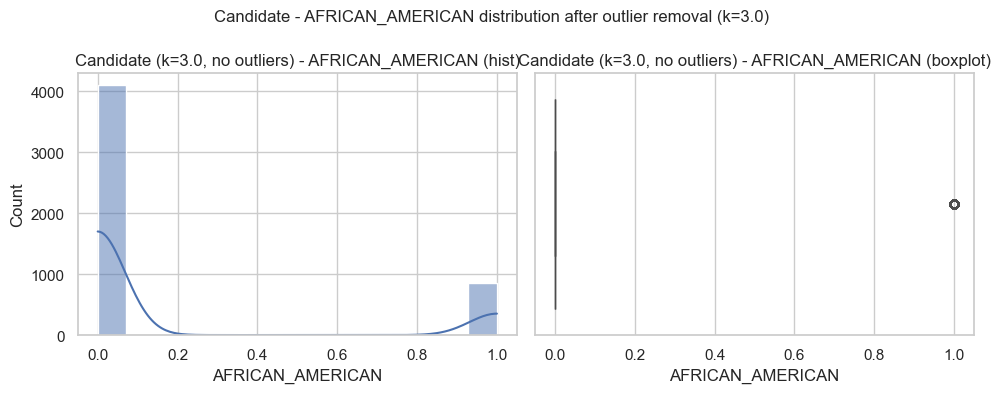

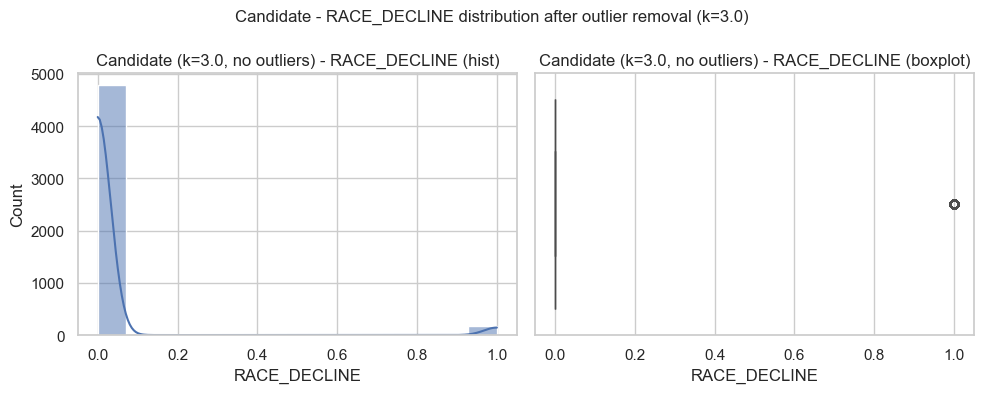

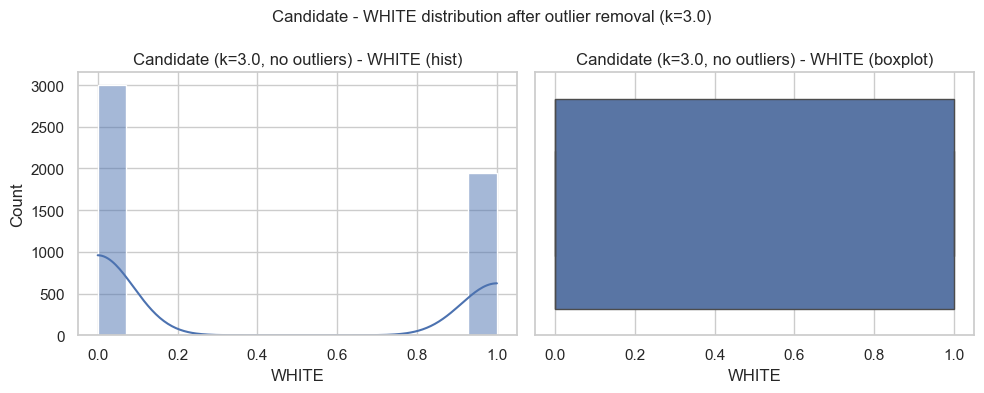

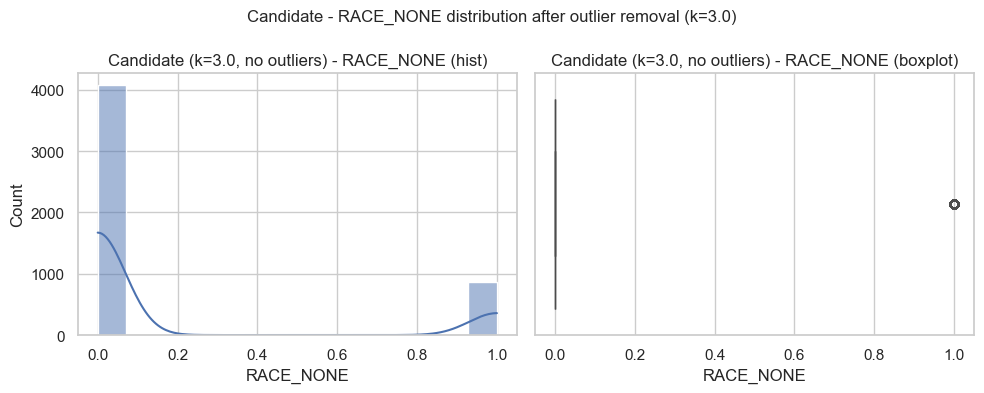

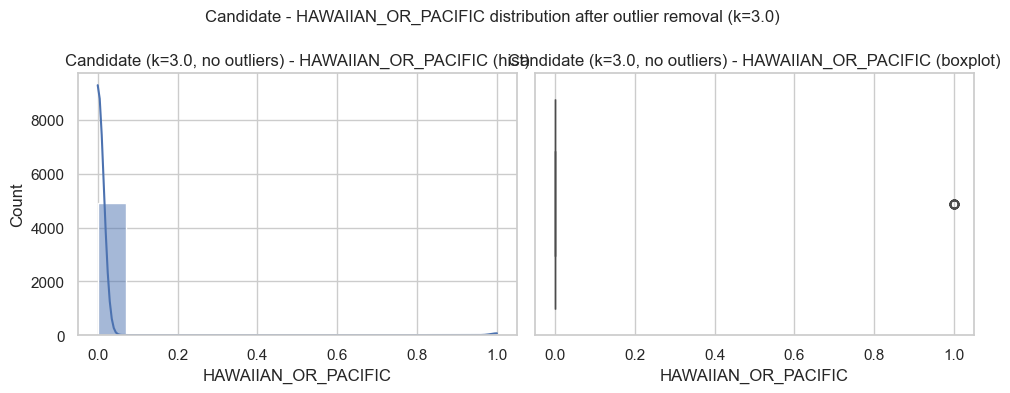

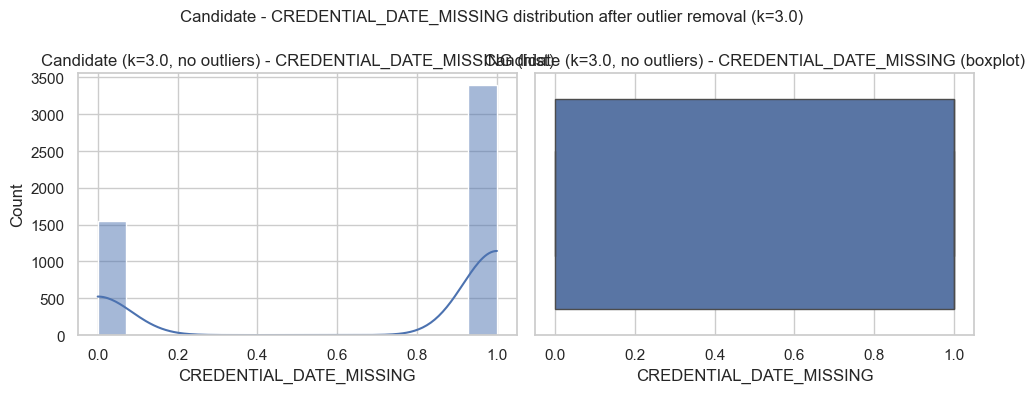

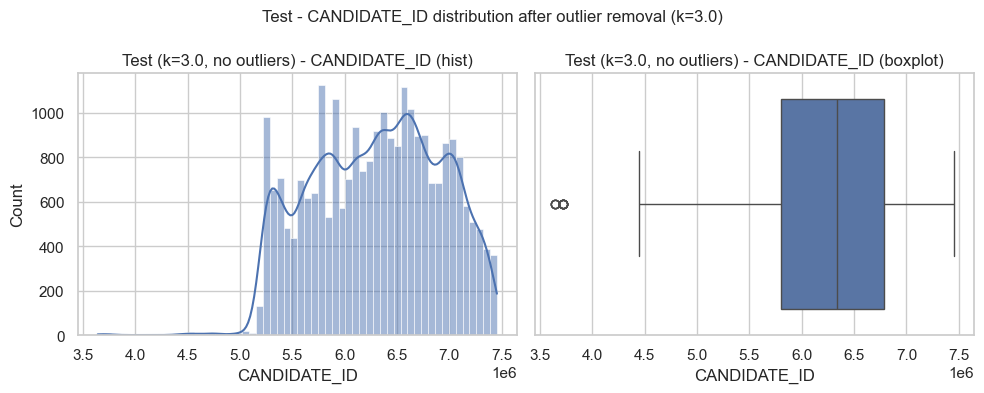

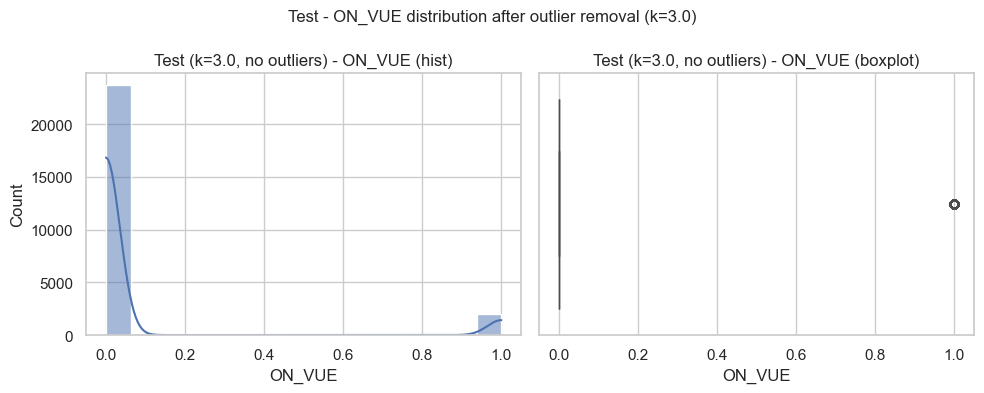

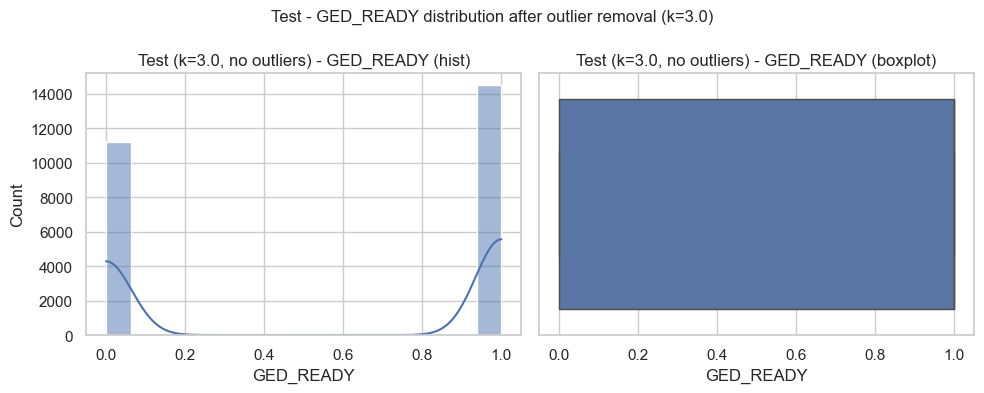

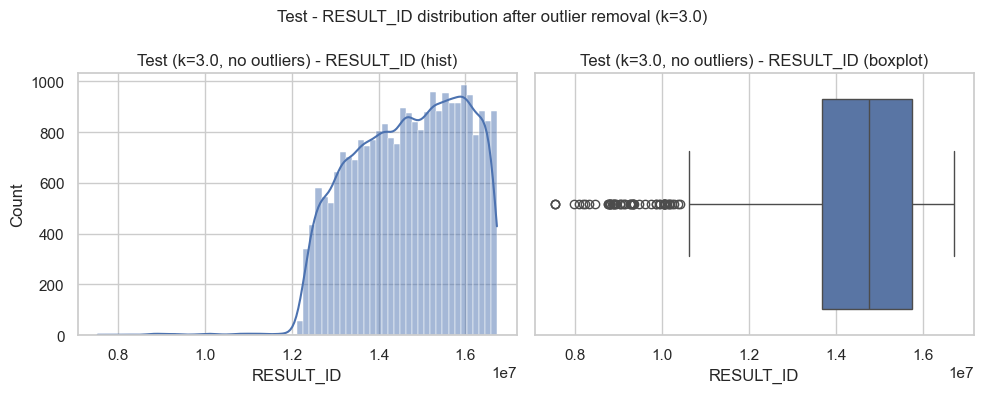

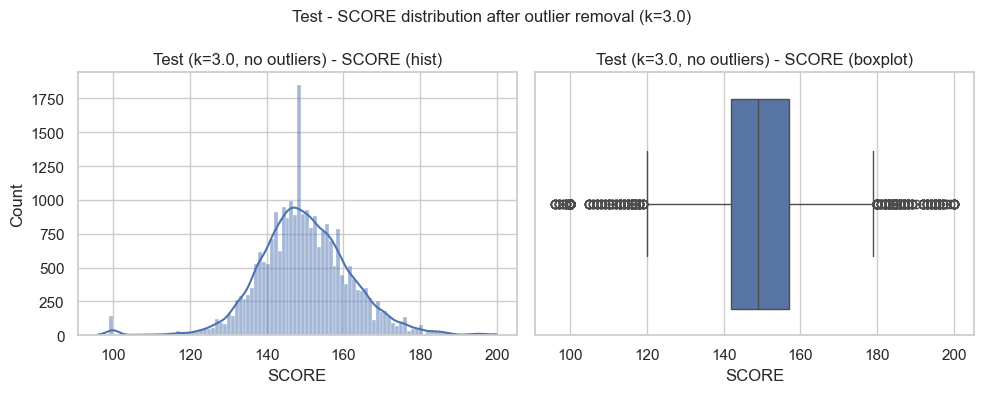

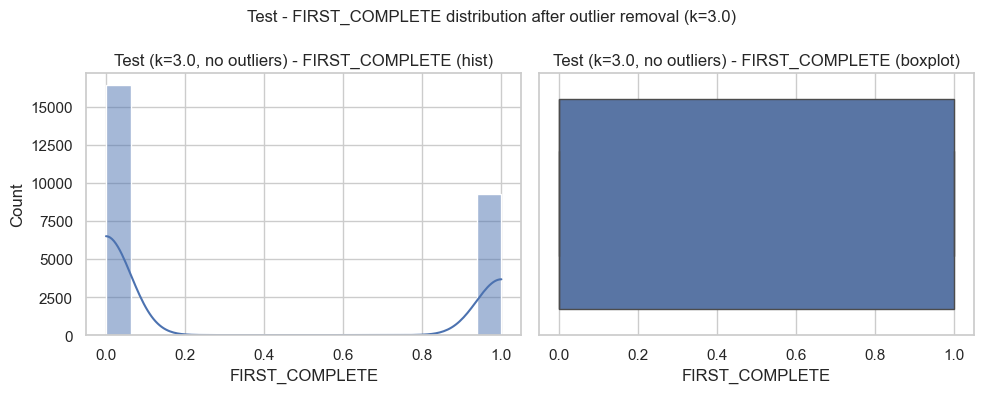

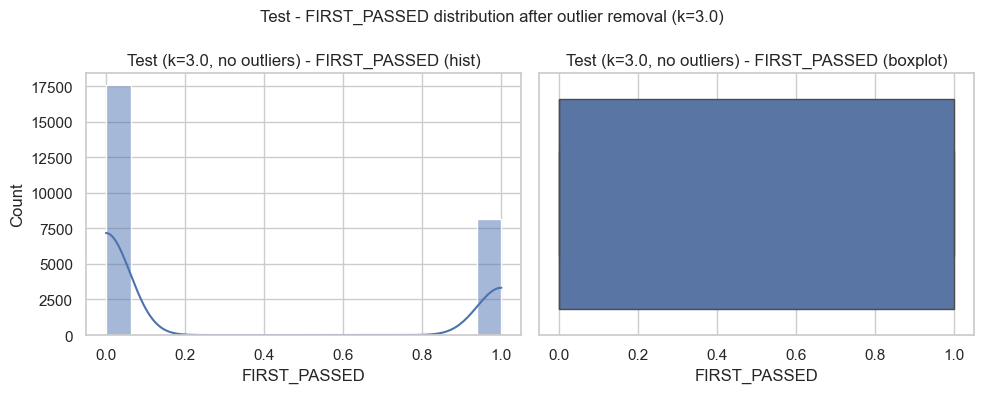

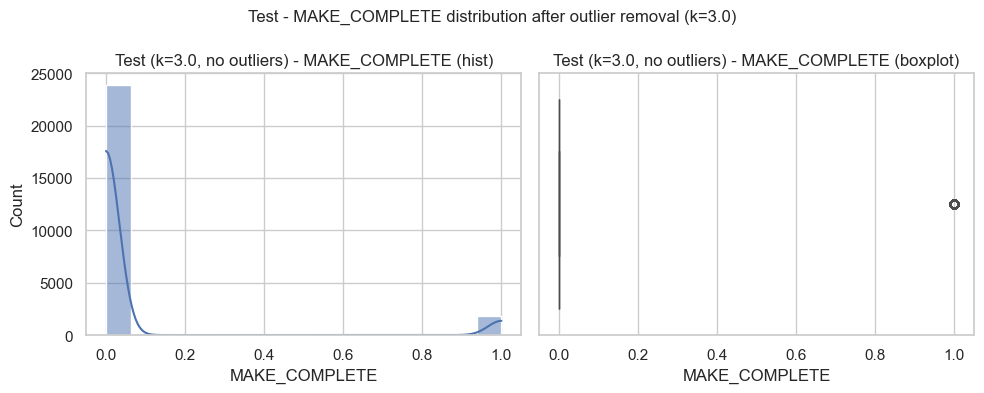

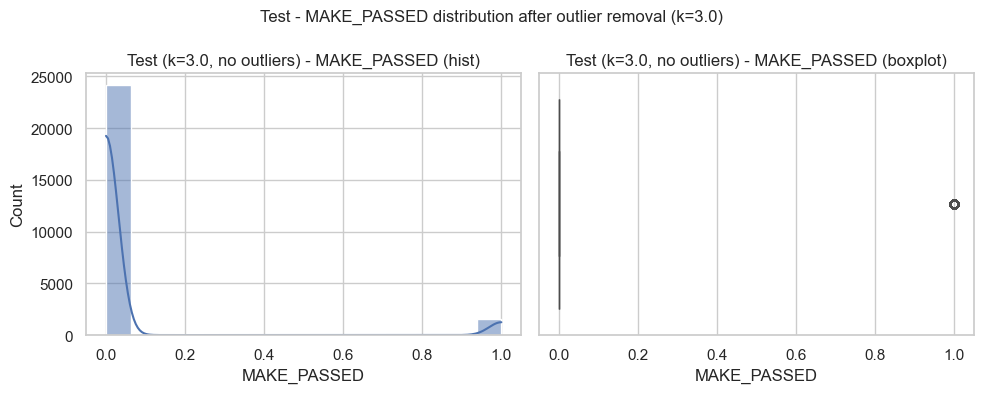

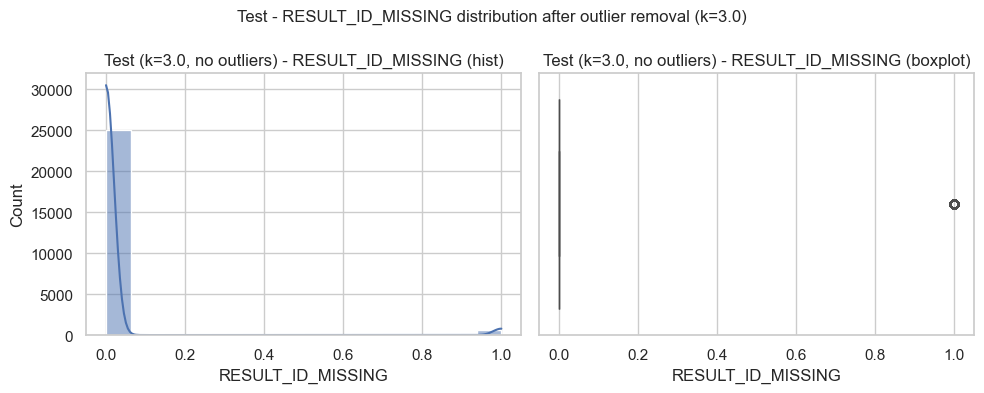

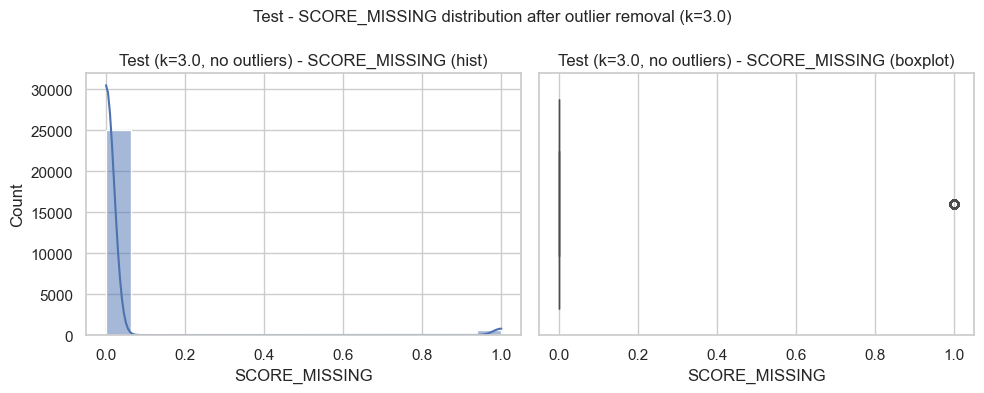

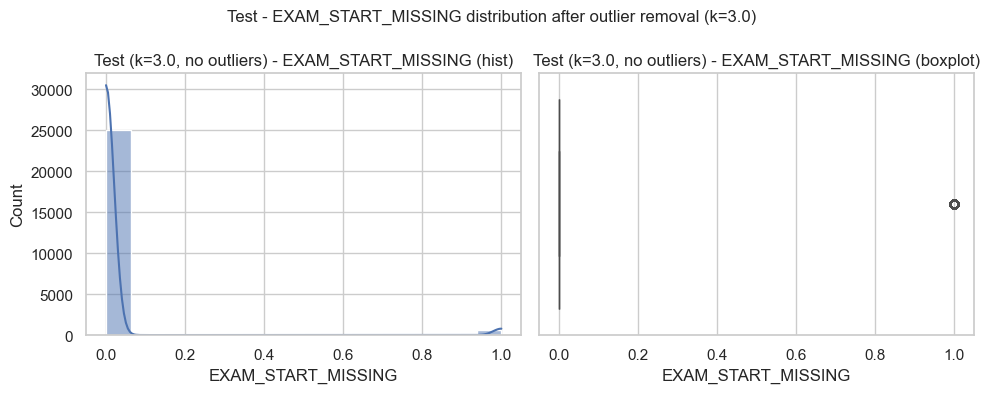


Summary of rows removed as outliers (k=3.0):
Candidate table (k=3.0):
  Total rows before: 5000
  Rows removed as outliers: 51
  Percentage removed: 1.02%

Test table (k=3.0):
  Total rows before: 27830
  Rows removed as outliers: 2135
  Percentage removed: 7.67%

Done (k=3.0 pipeline).


In [2]:
# Full pipeline with k=3.0: outlier removal, distribution summaries, and removal ratios

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ---------------------------------------------------------------------
# Paths and output locations (k = 3.0 version; does NOT change earlier cells)
# ---------------------------------------------------------------------
base_dir = Path(r"/Users/ankit/Downloads/EDA-Team assignment")

candidate_path = base_dir / "candidate_cleaned.xlsx"
test_path = base_dir / "test_cleaned.xlsx"

# Outlier outputs (k=3.0)
candidate_outliers_csv_k3 = base_dir / "candidate_outliers_k3.csv"
test_outliers_csv_k3 = base_dir / "test_outliers_k3.csv"

candidate_clean_no_outliers_xlsx_k3 = base_dir / "candidate_cleaned_no_outliers_k3.xlsx"
test_clean_no_outliers_xlsx_k3 = base_dir / "test_cleaned_no_outliers_k3.xlsx"

# Distribution summaries (k=3.0, based on outlier-removed data)
candidate_dist_summary_k3 = base_dir / "candidate_numeric_distribution_summary_k3.csv"
test_dist_summary_k3 = base_dir / "test_numeric_distribution_summary_k3.csv"


# ---------------------------------------------------------------------
# IQR-based outlier detection helper (default k = 3.0 here)
# ---------------------------------------------------------------------
def detect_outliers_iqr(df: pd.DataFrame, k: float = 3.0):
    """Return outlier flags per numeric column using the IQR rule.

    For each numeric column col:
        Q1, Q3 = 25%, 75% quantiles
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        flag if value < lower or value > upper

    Returns
    -------
    flags : DataFrame (bool)
        Same index as df, columns `<col>_is_outlier` for numeric columns.
    any_outlier : Series (bool)
        Row-wise flag: True if any numeric column is an outlier.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    flags = pd.DataFrame(index=df.index)

    for col in numeric_cols:
        series = df[col].dropna()
        if series.empty:
            flags[f"{col}_is_outlier"] = False
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        # If IQR is zero, skip this column (no spread)
        if iqr == 0:
            flags[f"{col}_is_outlier"] = False
            continue

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        col_flag = (df[col] < lower) | (df[col] > upper)
        flags[f"{col}_is_outlier"] = col_flag.fillna(False)

    any_outlier = flags.any(axis=1)
    return flags, any_outlier


# ---------------------------------------------------------------------
# 1) Outlier removal with k = 3.0
# ---------------------------------------------------------------------
print("Reading baseline cleaned datasets...")
candidate_df = pd.read_excel(candidate_path)
test_df = pd.read_excel(test_path)

print(f"Candidate shape before outlier removal: {candidate_df.shape}")
print(f"Test shape before outlier removal: {test_df.shape}")

# Candidate outlier detection (k=3.0)
print("\nRunning IQR-based outlier detection for candidate data (k=3.0)...")
candidate_flags_k3, candidate_any_k3 = detect_outliers_iqr(candidate_df, k=3.0)

candidate_with_flags_k3 = pd.concat([candidate_df, candidate_flags_k3], axis=1)
candidate_with_flags_k3["any_outlier_k3"] = candidate_any_k3

candidate_outliers_k3 = candidate_with_flags_k3[candidate_with_flags_k3["any_outlier_k3"]]

print(f"Candidate outlier rows (k=3.0): {candidate_outliers_k3.shape[0]}")

# Save candidate outlier rows (with flag columns) to CSV
candidate_outliers_k3.to_csv(candidate_outliers_csv_k3, index=False)
print(f"Candidate outliers (k=3.0) saved to: {candidate_outliers_csv_k3}")

# Save candidate data with outliers removed (k=3.0)
candidate_no_outliers_k3 = candidate_with_flags_k3[~candidate_with_flags_k3["any_outlier_k3"]]
flag_cols_candidate_k3 = [
    c for c in candidate_no_outliers_k3.columns
    if c.endswith("_is_outlier") or c == "any_outlier_k3"
]

candidate_no_outliers_k3_clean = candidate_no_outliers_k3.drop(columns=flag_cols_candidate_k3)

candidate_no_outliers_k3_clean.to_excel(candidate_clean_no_outliers_xlsx_k3, index=False)
print(f"Candidate cleaned (no outliers, k=3.0) saved to: {candidate_clean_no_outliers_xlsx_k3}")


# Test outlier detection (k=3.0)
print("\nRunning IQR-based outlier detection for test data (k=3.0)...")
test_flags_k3, test_any_k3 = detect_outliers_iqr(test_df, k=3.0)

test_with_flags_k3 = pd.concat([test_df, test_flags_k3], axis=1)
test_with_flags_k3["any_outlier_k3"] = test_any_k3

test_outliers_k3 = test_with_flags_k3[test_with_flags_k3["any_outlier_k3"]]

print(f"Test outlier rows (k=3.0): {test_outliers_k3.shape[0]}")

# Save test outlier rows (with flag columns) to CSV
test_outliers_k3.to_csv(test_outliers_csv_k3, index=False)
print(f"Test outliers (k=3.0) saved to: {test_outliers_csv_k3}")

# Save test data with outliers removed (k=3.0)
test_no_outliers_k3 = test_with_flags_k3[~test_with_flags_k3["any_outlier_k3"]]
flag_cols_test_k3 = [
    c for c in test_no_outliers_k3.columns
    if c.endswith("_is_outlier") or c == "any_outlier_k3"
]

test_no_outliers_k3_clean = test_no_outliers_k3.drop(columns=flag_cols_test_k3)

test_no_outliers_k3_clean.to_excel(test_clean_no_outliers_xlsx_k3, index=False)
print(f"Test cleaned (no outliers, k=3.0) saved to: {test_clean_no_outliers_xlsx_k3}")


# ---------------------------------------------------------------------
# 2) Distribution checks (using outlier-removed data, k = 3.0)
# ---------------------------------------------------------------------
print("\nRunning distribution checks on outlier-removed data (k=3.0)...")

sns.set(style="whitegrid")

# Use k=3.0 cleaned data for distribution analysis
candidate_for_dist = candidate_no_outliers_k3_clean
test_for_dist = test_no_outliers_k3_clean

candidate_num_cols_k3 = candidate_for_dist.select_dtypes(include=np.number).columns.tolist()
test_num_cols_k3 = test_for_dist.select_dtypes(include=np.number).columns.tolist()

print("Candidate numeric columns (k=3.0 cleaned):", candidate_num_cols_k3)
print("Test numeric columns (k=3.0 cleaned):", test_num_cols_k3)

# Save basic distribution statistics (k=3.0 cleaned)
candidate_desc_k3 = candidate_for_dist[candidate_num_cols_k3].describe(percentiles=[0.25, 0.5, 0.75]).T
test_desc_k3 = test_for_dist[test_num_cols_k3].describe(percentiles=[0.25, 0.5, 0.75]).T

candidate_desc_k3.to_csv(candidate_dist_summary_k3)
test_desc_k3.to_csv(test_dist_summary_k3)

print("Saved candidate numeric distribution summary (k=3.0) to:", candidate_dist_summary_k3)
print("Saved test numeric distribution summary (k=3.0) to:", test_dist_summary_k3)

# Plot histograms + boxplots (after outlier removal, k=3.0)
for col in candidate_num_cols_k3:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(candidate_for_dist[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Candidate (k=3.0, no outliers) - {col} (hist)")

    sns.boxplot(x=candidate_for_dist[col], ax=axes[1])
    axes[1].set_title(f"Candidate (k=3.0, no outliers) - {col} (boxplot)")

    fig.suptitle(f"Candidate - {col} distribution after outlier removal (k=3.0)", fontsize=12)
    plt.tight_layout()
    plt.show()

for col in test_num_cols_k3:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(test_for_dist[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Test (k=3.0, no outliers) - {col} (hist)")

    sns.boxplot(x=test_for_dist[col], ax=axes[1])
    axes[1].set_title(f"Test (k=3.0, no outliers) - {col} (boxplot)")

    fig.suptitle(f"Test - {col} distribution after outlier removal (k=3.0)", fontsize=12)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 3) How many rows were removed as outliers with k = 3.0?
# ---------------------------------------------------------------------
print("\nSummary of rows removed as outliers (k=3.0):")

cand_total_k3 = len(candidate_df)
cand_after_k3 = len(candidate_no_outliers_k3_clean)
cand_removed_k3 = cand_total_k3 - cand_after_k3
cand_ratio_k3 = cand_removed_k3 / cand_total_k3 if cand_total_k3 > 0 else 0

test_total_k3 = len(test_df)
test_after_k3 = len(test_no_outliers_k3_clean)
test_removed_k3 = test_total_k3 - test_after_k3
test_ratio_k3 = test_removed_k3 / test_total_k3 if test_total_k3 > 0 else 0

print("Candidate table (k=3.0):")
print(f"  Total rows before: {cand_total_k3}")
print(f"  Rows removed as outliers: {cand_removed_k3}")
print(f"  Percentage removed: {cand_ratio_k3:.2%}")

print("\nTest table (k=3.0):")
print(f"  Total rows before: {test_total_k3}")
print(f"  Rows removed as outliers: {test_removed_k3}")
print(f"  Percentage removed: {test_ratio_k3:.2%}")

print("\nDone (k=3.0 pipeline).")